In [259]:
import pandas as pd
df = pd.read_csv('./data/cytof.csv', index_col=0)

In [260]:
df_ts = df[(df.observableId == 'p.ERK') & (df.simulationConditionId.str.endswith('__EGF'))].pivot_table(index='preequilibrationConditionId', columns='time', values='measurement')

In [261]:
df_ts

time,0.0,5.5,7.0,9.0,12.0,13.0,14.0,17.0,23.0,30.0,35.0,40.0,60.0
preequilibrationConditionId,,,,,,,,,,,,,
c184A1,2.610448,3.562203,3.503852,3.677882,NaN,3.522100,NaN,3.333949,3.631606,3.225276,NaN,2.997180,2.794183
c184B5,2.303940,3.657244,3.324000,3.025286,NaN,3.918409,NaN,3.321868,3.713584,2.687524,NaN,2.625606,2.612064
cBT20,3.805443,3.990476,4.411401,4.240665,NaN,3.993469,NaN,4.529850,3.900909,4.510031,NaN,3.737119,4.148405
cBT474,3.089931,3.320202,3.088775,3.261580,NaN,3.459100,NaN,3.215458,2.978081,3.171048,NaN,2.903087,3.052457
cBT483,2.941606,3.898188,3.991941,3.743703,NaN,3.468802,NaN,3.100587,3.201544,2.630544,NaN,2.680406,2.462154
cBT549,2.774730,3.805003,3.986812,3.723047,NaN,3.315204,NaN,3.625836,3.330300,3.653468,NaN,3.253072,3.417519
cCAL148,1.969755,3.532953,3.275293,3.478243,NaN,3.335307,NaN,3.302267,3.362060,3.269086,NaN,2.330384,2.884917
cCAL51,2.625466,4.037332,3.771651,3.893120,NaN,3.844919,NaN,3.386502,3.715885,3.631095,NaN,3.872647,3.624477
cCAL851,3.290168,3.821046,3.551637,3.818823,NaN,3.651139,NaN,3.306332,3.510824,3.157344,NaN,3.232957,2.764083


In [262]:
import numpy as np
from dataclasses import dataclass
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def _sigmoid(x, center, width):
    # width > 0 makes the transition slope ~1/width; allow negative for decreasing steps
    return 1.0 / (1.0 + np.exp(-(x - center) / width))

def double_sigmoid_product(x, A, B, c1, w1, C, c2, w2):
    """
    Model: y = B + A * sigmoid((x-c1)/w1) * sigmoid((x-c2)/w2)
      A: amplitude (scale of the product)
      B: baseline (offset)
      c1, c2: centers of the two sigmoids
      w1, w2: widths (slope controls; can be negative for decreasing steps)
    """
    return A + B * _sigmoid(x, c1, np.power(10,w1)) - (B+C)* np.heaviside(x-c2,0.0) * (1-np.exp(-np.power(10,w2)*(x-c2)))

@dataclass
class FitResult:
    params: dict
    popt: np.ndarray
    pcov: np.ndarray
    stderr: np.ndarray
    params_stderr: dict
    p0: dict


def fit_double_sigmoid(x, y, max_nfev=20000, plot=False):
    """
    Fit y ~ B + A * s1 * s2 with scipy.optimize.curve_fit.

    Parameters
    ----------
    x, y : 1D arrays
    max_nfev : max function evaluations

    Returns
    -------
    FitResult with dict of params, covariance, and standard errors.
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    param_names = ['A', 'B', 'c1', 'w1', 'C', 'c2', 'w2']

    # Default initial guesses
    A0 = y[0]
    B0 = y.max() - A0
    c10 = 2
    w10 = -0.5
    C0 = y[0] - y[-1]
    c20 = 10
    w20 = -1.5
    p0 =    [ A0,     B0,  c10,  w10,  C0,  c20,  w20]

    lower = [ A0-0.2, 0,   1,    -1,  -2,   5,   -3]
    upper = [ A0+0.2, 3,   5,   -0.5,    2,   20,   0.0]
    bounds = (lower, upper)

    def _fit(weights=None):
        sigma = None
        if weights is not None:
            # curve_fit uses sigma as std; supply std = 1/sqrt(weight)
            sigma = 1.0 / np.sqrt(np.clip(weights, 1e-12, np.inf))

        popt, pcov = curve_fit(
            double_sigmoid_product,
            x,
            y,
            p0=p0,
            sigma=sigma,
            absolute_sigma=(sigma is not None),
            bounds=bounds,
            max_nfev=max_nfev,
        )
        return popt, pcov

    # Stage 1: standard (or weighted) LS
    popt, pcov = _fit()

    # Compute residuals, build Huber weights, refit
    yhat = double_sigmoid_product(x, *popt)
    resid = y - yhat
    # Huber scale via MAD
    mad = np.median(np.abs(resid - np.median(resid))) + 1e-12
    c = 1.345  # Huber tuning
    r = resid / (1.4826 * mad)
    w = np.where(np.abs(r) <= c, 1.0, (c / np.abs(r)) )
    popt, pcov = _fit(weights=w)

    # Standard errors from covariance
    stderr = np.sqrt(np.maximum(np.diag(pcov), 0.0))

    params = dict(zip(param_names, popt))
    params_stderr = dict(zip(param_names, stderr))
    params_0 = dict(zip(param_names, p0))
    if plot:
        plt.figure()
        plt.scatter(x, y, label='data')
        x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        y_fit = double_sigmoid_product(x_fit, *popt)
        y0 = double_sigmoid_product(x_fit, *p0)
        plt.plot(x_fit, y_fit, 'r-', label='fit')
        plt.plot(x_fit, y0, 'b-', label='init')
        plt.legend()
        plt.show()
    return FitResult(params=params, popt=popt, pcov=pcov, stderr=stderr, params_stderr=params_stderr, p0=params_0)

In [195]:
?curve_fit

Fitting row 0 (c184A1)


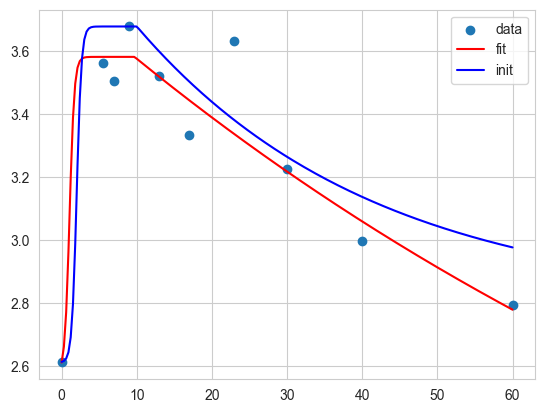

{'A': np.float64(2.5758522350443727), 'B': np.float64(1.005460695771452), 'c1': np.float64(1.054412276596112), 'w1': np.float64(-0.500010499629524), 'C': np.float64(1.3701162609695443), 'c2': np.float64(9.692703825192776), 'w2': np.float64(-2.086061786059643)}
Fitting row 1 (c184B5)


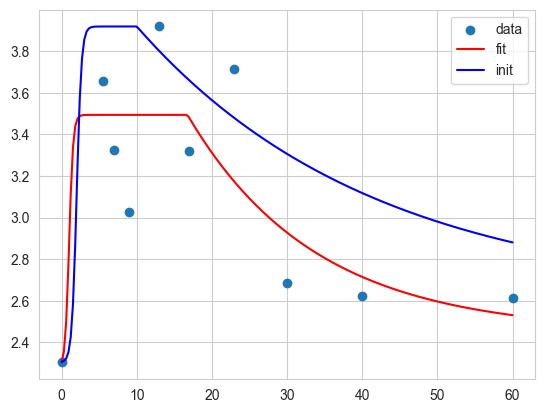

{'A': np.float64(2.2767645445281923), 'B': np.float64(1.216915797648266), 'c1': np.float64(1.0001321879072962), 'w1': np.float64(-0.5773436370511695), 'C': np.float64(-0.17295784429274166), 'c2': np.float64(16.743851510735414), 'w2': np.float64(-1.2298238791674414)}
Fitting row 2 (cBT20)


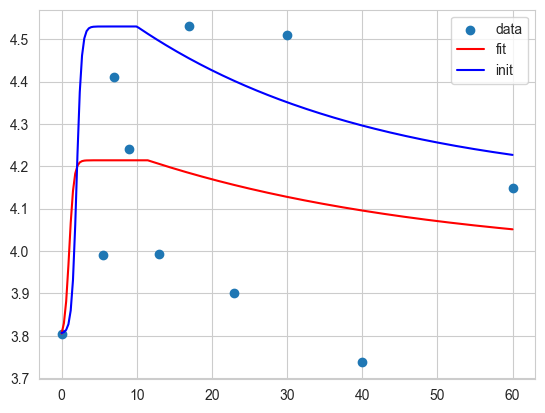

{'A': np.float64(3.788503142025022), 'B': np.float64(0.425613668958597), 'c1': np.float64(1.0066474678425579), 'w1': np.float64(-0.5000000000029527), 'C': np.float64(-0.19607027768959495), 'c2': np.float64(11.482726391150678), 'w2': np.float64(-1.5940963356617432)}
Fitting row 3 (cBT474)


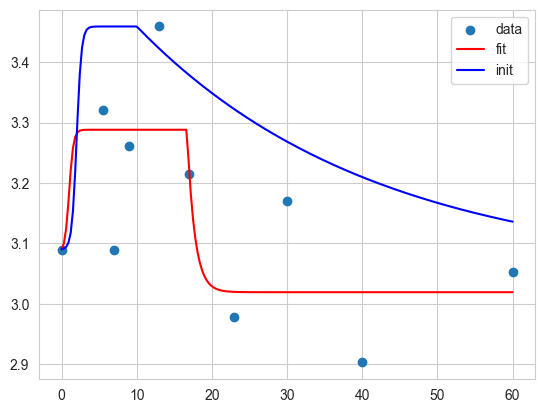

{'A': np.float64(3.083759113794905), 'B': np.float64(0.20443972748207523), 'c1': np.float64(1.0001530943705514), 'w1': np.float64(-0.5402127324148032), 'C': np.float64(0.06436201467006394), 'c2': np.float64(16.683925301158155), 'w2': np.float64(-1.8450089470665238e-13)}
Fitting row 4 (cBT483)


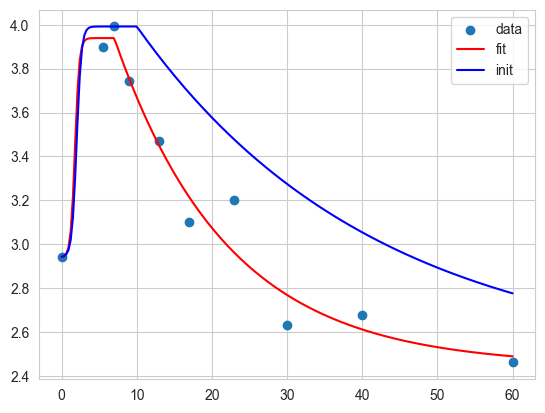

{'A': np.float64(2.9394779018820154), 'B': np.float64(0.9996317667834713), 'c1': np.float64(1.7770062214287758), 'w1': np.float64(-0.5409356467492783), 'C': np.float64(0.49308511260001164), 'c2': np.float64(7.000000116577002), 'w2': np.float64(-1.1768827057972227)}
Fitting row 5 (cBT549)


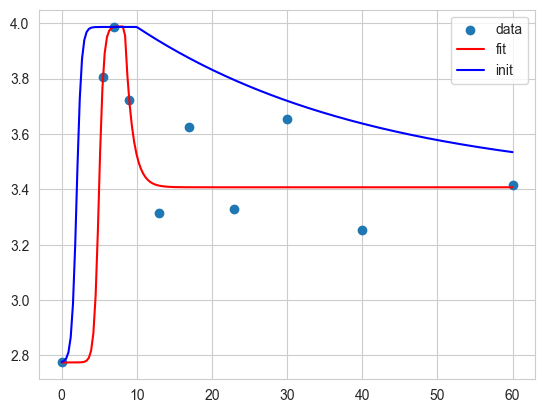

{'A': np.float64(2.7747294479319358), 'B': np.float64(1.2138879273128154), 'c1': np.float64(4.959264613983746), 'w1': np.float64(-0.5037394848782025), 'C': np.float64(-0.632925480864143), 'c2': np.float64(8.383852741606628), 'w2': np.float64(-6.907748086311556e-35)}
Fitting row 6 (cCAL148)


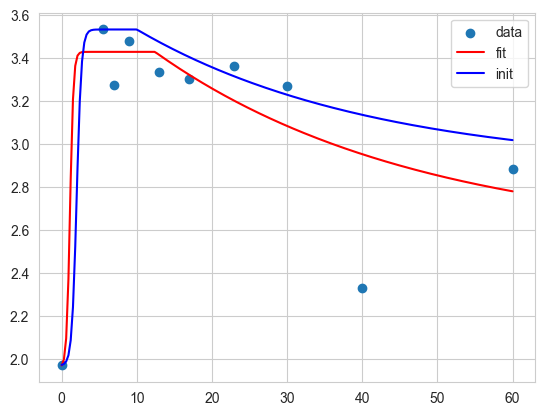

{'A': np.float64(1.9594340493280635), 'B': np.float64(1.4693924551734299), 'c1': np.float64(1.1165799780600913), 'w1': np.float64(-0.6468420020174698), 'C': np.float64(-0.5966887348838054), 'c2': np.float64(12.408956881428736), 'w2': np.float64(-1.5438917822328635)}
Fitting row 7 (cCAL51)


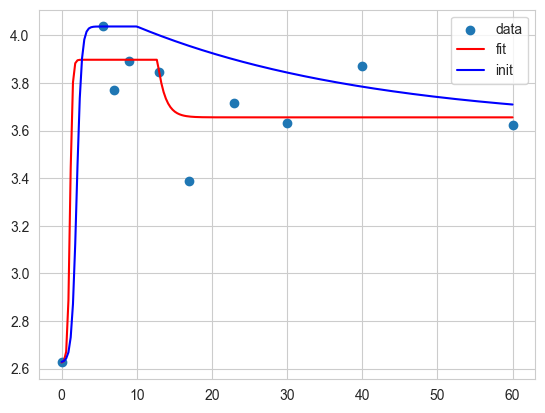

{'A': np.float64(2.624461578297915), 'B': np.float64(1.2730451091135295), 'c1': np.float64(1.1148043861452082), 'w1': np.float64(-0.8066911232905282), 'C': np.float64(-1.0310058331102356), 'c2': np.float64(12.745897101612227), 'w2': np.float64(-9.293813461984429e-16)}
Fitting row 8 (cCAL851)


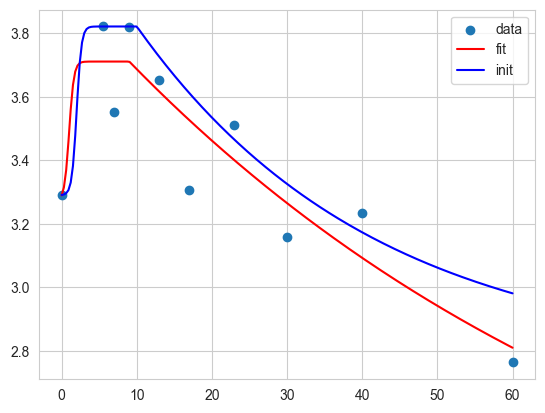

{'A': np.float64(3.271743394029757), 'B': np.float64(0.43897356660320624), 'c1': np.float64(1.0000943127880306), 'w1': np.float64(-0.5000000000729967), 'C': np.float64(1.3865095434754495), 'c2': np.float64(8.999999930035923), 'w2': np.float64(-1.8753647779300324)}
Fitting row 9 (cDU4475)


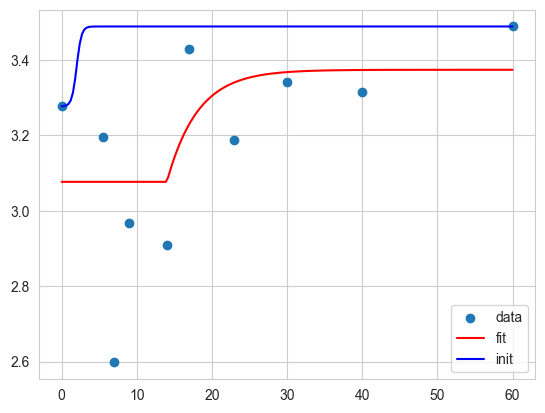

{'A': np.float64(3.076699147855689), 'B': np.float64(8.398215052143423e-13), 'c1': np.float64(1.0000000010220815), 'w1': np.float64(-0.5000000000000001), 'C': np.float64(-0.29715299028909875), 'c2': np.float64(13.999999818288641), 'w2': np.float64(-0.6147329250910494)}
Fitting row 10 (cEFM192A)


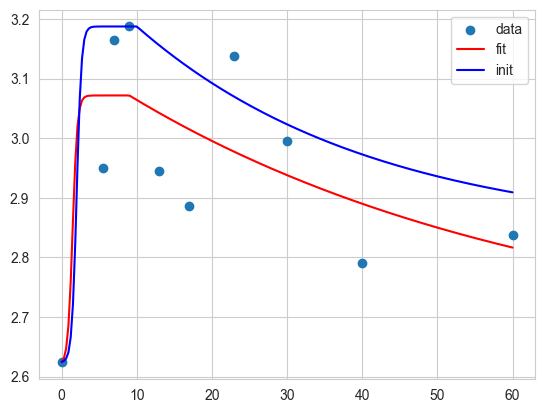

{'A': np.float64(2.619163047676579), 'B': np.float64(0.45242423467130927), 'c1': np.float64(1.4608293649887267), 'w1': np.float64(-0.5000000000412324), 'C': np.float64(-0.02763509264971009), 'c2': np.float64(9.000000393681708), 'w2': np.float64(-1.7445133194273483)}
Fitting row 11 (cEVSAT)


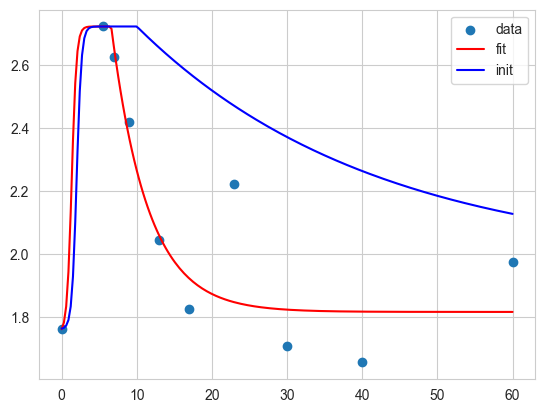

{'A': np.float64(1.7480582113177205), 'B': np.float64(0.9730286945724289), 'c1': np.float64(1.340718958888243), 'w1': np.float64(-0.500707102357095), 'C': np.float64(-0.0684457838828935), 'c2': np.float64(6.59378626339787), 'w2': np.float64(-0.6854239629535216)}
Fitting row 12 (cHBL100)


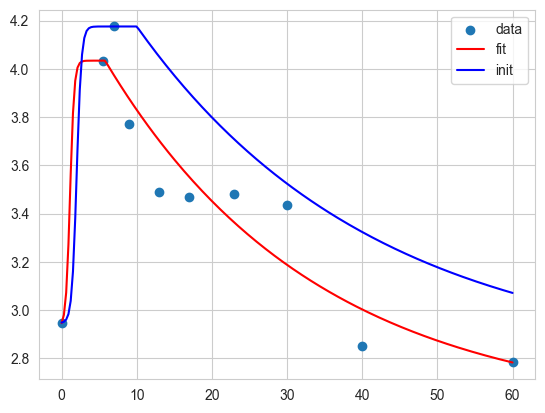

{'A': np.float64(2.927913428916126), 'B': np.float64(1.1061647312470886), 'c1': np.float64(1.1224697782697608), 'w1': np.float64(-0.5627735841340712), 'C': np.float64(0.35584386754996433), 'c2': np.float64(5.781689085824732), 'w2': np.float64(-1.4468939429749617)}
Fitting row 13 (cHCC1187)


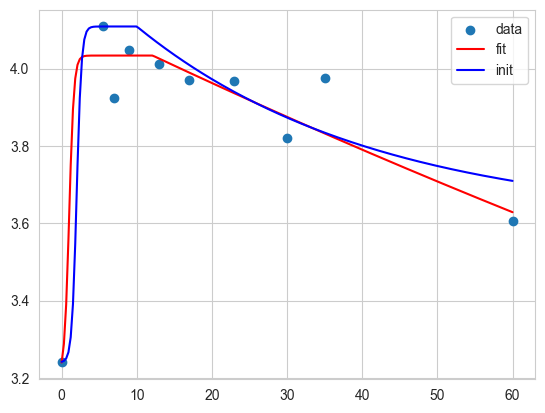

{'A': np.float64(3.2061502070788013), 'B': np.float64(0.8278131142990125), 'c1': np.float64(1.0000000000000002), 'w1': np.float64(-0.5000000000000001), 'C': np.float64(1.9999999998620257), 'c2': np.float64(12.110123580017014), 'w2': np.float64(-2.4907095561680603)}
Fitting row 14 (cHCC1395)


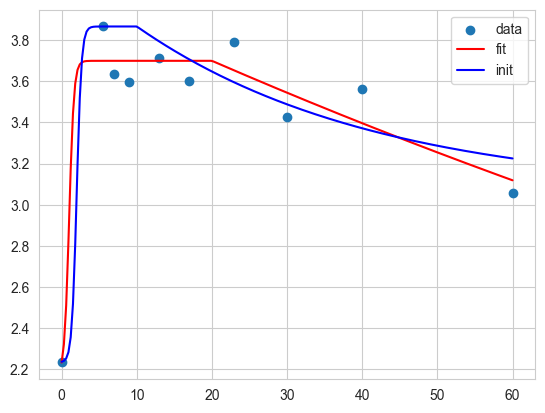

{'A': np.float64(2.170901794548719), 'B': np.float64(1.5284933235817189), 'c1': np.float64(1.0000000000000002), 'w1': np.float64(-0.5000000000000001), 'C': np.float64(1.9999999999999998), 'c2': np.float64(19.999999999999996), 'w2': np.float64(-2.347115786998309)}
Fitting row 15 (cHCC1419)


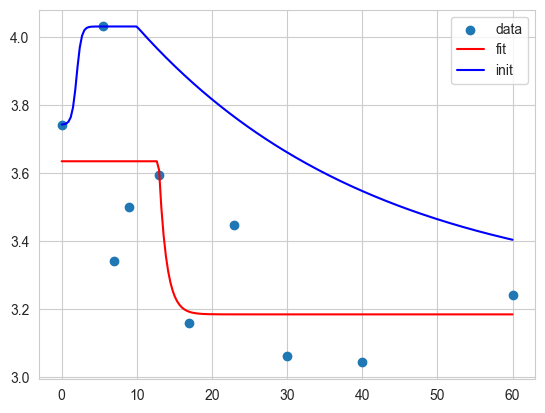

{'A': np.float64(3.634636102596062), 'B': np.float64(2.602903902420699e-19), 'c1': np.float64(1.0447107369697386), 'w1': np.float64(-0.9999982541305326), 'C': np.float64(0.45095614098135967), 'c2': np.float64(12.906454081348743), 'w2': np.float64(-3.0868540664721974e-05)}
Fitting row 16 (cHCC1428)


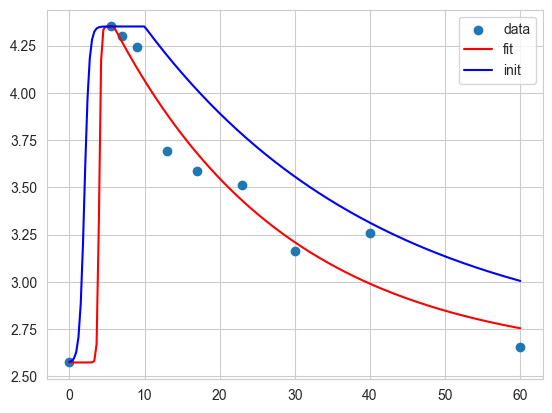

{'A': np.float64(2.5731412864204426), 'B': np.float64(1.777872956841523), 'c1': np.float64(3.9597930212722963), 'w1': np.float64(-0.9221651185942547), 'C': np.float64(-0.008260658181596948), 'c2': np.float64(5.9042069080738875), 'w2': np.float64(-1.3664271146685874)}
Fitting row 17 (cHCC1500)


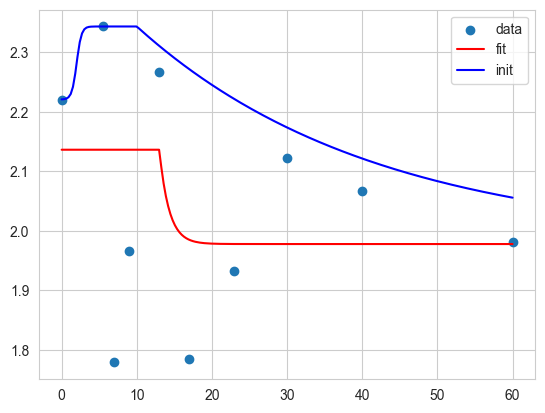

{'A': np.float64(2.136307028446279), 'B': np.float64(2.9453800131746095e-06), 'c1': np.float64(1.0038984765449508), 'w1': np.float64(-0.5000000002141837), 'C': np.float64(0.15842494942001734), 'c2': np.float64(13.000000256731894), 'w2': np.float64(-0.10901044641944005)}
Fitting row 18 (cHCC1569)


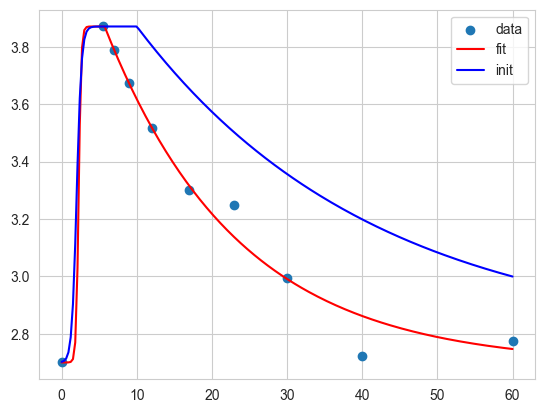

{'A': np.float64(2.699711732436928), 'B': np.float64(1.1714165752479446), 'c1': np.float64(2.265880010550562), 'w1': np.float64(-0.780863533077368), 'C': np.float64(0.00796021650867091), 'c2': np.float64(5.716888105837116), 'w2': np.float64(-1.2479021658914087)}
Fitting row 19 (cHCC1806)


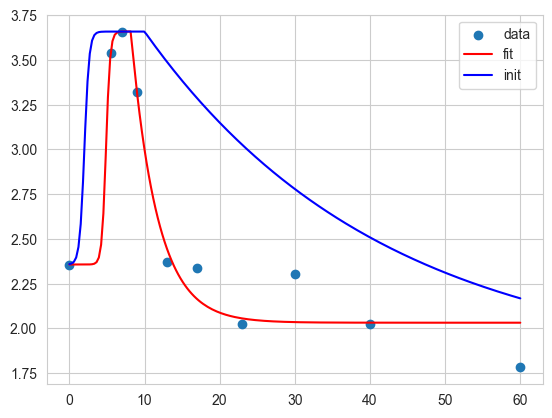

{'A': np.float64(2.3570957168306528), 'B': np.float64(1.3016247559681555), 'c1': np.float64(4.871097608863915), 'w1': np.float64(-0.5625744694209541), 'C': np.float64(0.3250426612719216), 'c2': np.float64(8.16961455771055), 'w2': np.float64(-0.5457325677836602)}
Fitting row 20 (cHCC1937)


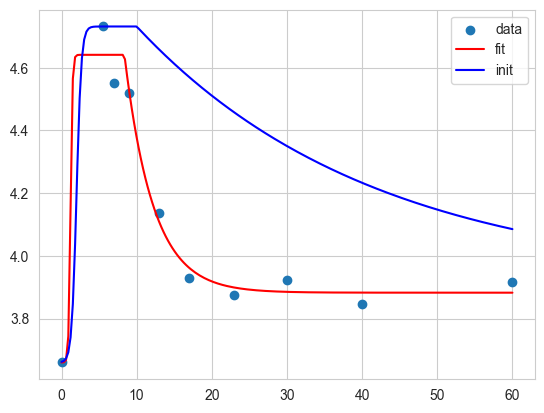

{'A': np.float64(3.6600729578194398), 'B': np.float64(0.9811332039470309), 'c1': np.float64(1.1991487434634869), 'w1': np.float64(-0.9051965424614071), 'C': np.float64(-0.2226173545847038), 'c2': np.float64(8.370839503993805), 'w2': np.float64(-0.5815437921921615)}
Fitting row 21 (cHCC1954)


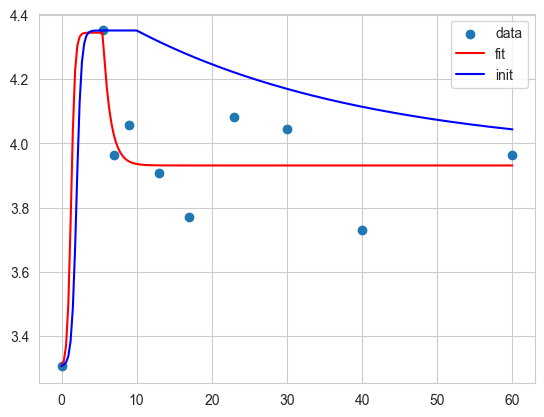

{'A': np.float64(3.298668680060178), 'B': np.float64(1.0458869231019219), 'c1': np.float64(1.2767108363352517), 'w1': np.float64(-0.5879626623375308), 'C': np.float64(-0.6327900494923071), 'c2': np.float64(5.49323984832209), 'w2': np.float64(-8.670665279732473e-14)}
Fitting row 22 (cHCC202)


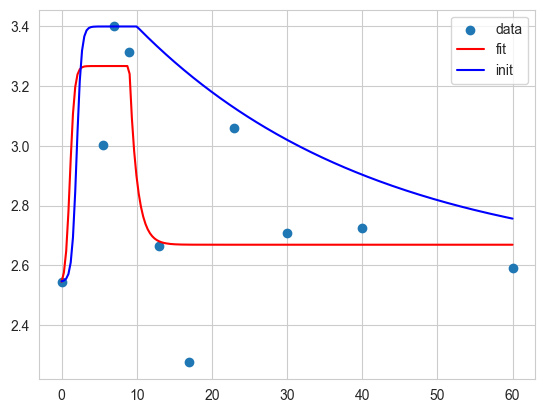

{'A': np.float64(2.5250068662282077), 'B': np.float64(0.7413277803909762), 'c1': np.float64(1.106332057743294), 'w1': np.float64(-0.5085204379486439), 'C': np.float64(-0.14408907248108815), 'c2': np.float64(9.000000071377812), 'w2': np.float64(-0.0009353403444625946)}
Fitting row 23 (cHCC2185)


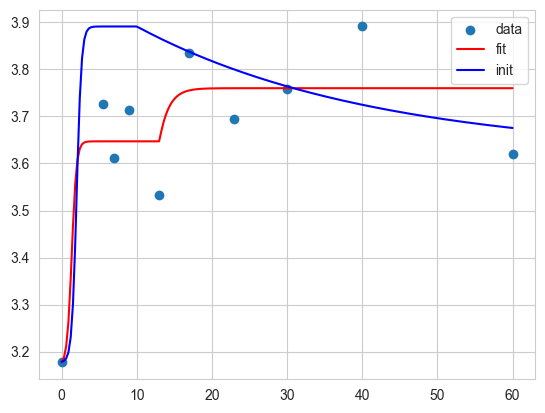

{'A': np.float64(3.170299854261495), 'B': np.float64(0.4768204553024042), 'c1': np.float64(1.3497080842359), 'w1': np.float64(-0.50194795664881), 'C': np.float64(-0.5898328513935843), 'c2': np.float64(13.000000021825333), 'w2': np.float64(-0.09866889689581967)}
Fitting row 24 (cHCC3153)


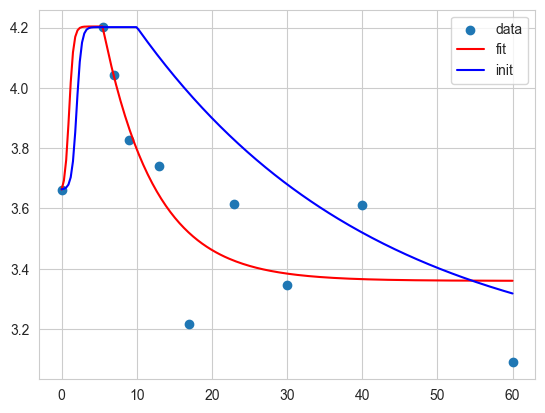

{'A': np.float64(3.6442436808247085), 'B': np.float64(0.5594352634592293), 'c1': np.float64(1.000050523978731), 'w1': np.float64(-0.5278168202039437), 'C': np.float64(0.28439575432201575), 'c2': np.float64(5.4479956556998195), 'w2': np.float64(-0.8388029465920894)}
Fitting row 25 (cHCC38)


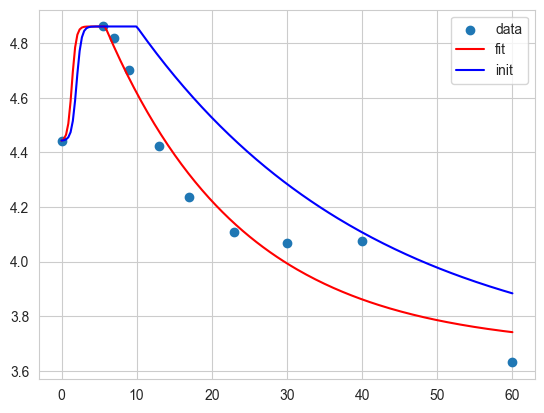

{'A': np.float64(4.439172878120314), 'B': np.float64(0.42144313465929345), 'c1': np.float64(1.3820651285010321), 'w1': np.float64(-0.5476222041422969), 'C': np.float64(0.757221592249377), 'c2': np.float64(5.799981427080493), 'w2': np.float64(-1.2599033848838128)}
Fitting row 26 (cHCC70)


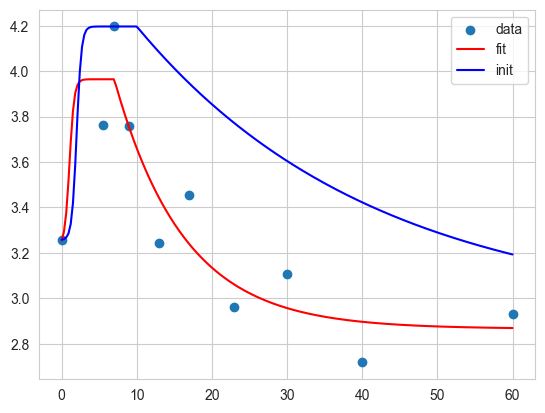

{'A': np.float64(3.228547234603472), 'B': np.float64(0.7357449788562251), 'c1': np.float64(1.0479064216919298), 'w1': np.float64(-0.5000000000060651), 'C': np.float64(0.3630115137154472), 'c2': np.float64(7.000000121332135), 'w2': np.float64(-0.9658798346734218)}
Fitting row 27 (cHDQP1)


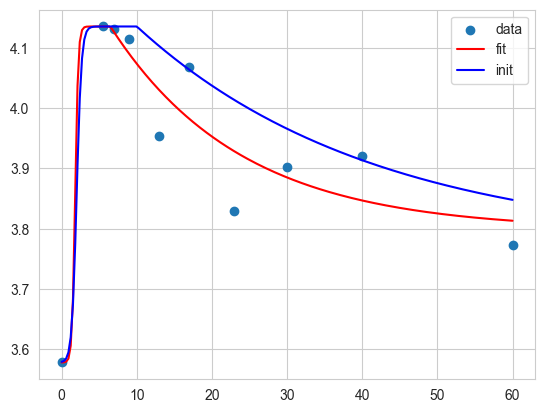

{'A': np.float64(3.5780804309069327), 'B': np.float64(0.5575057322320218), 'c1': np.float64(1.8007289208987016), 'w1': np.float64(-0.6949665557983766), 'C': np.float64(-0.2196944728472823), 'c2': np.float64(6.481167491293445), 'w2': np.float64(-1.2400544470599786)}
Fitting row 28 (cHs578T)


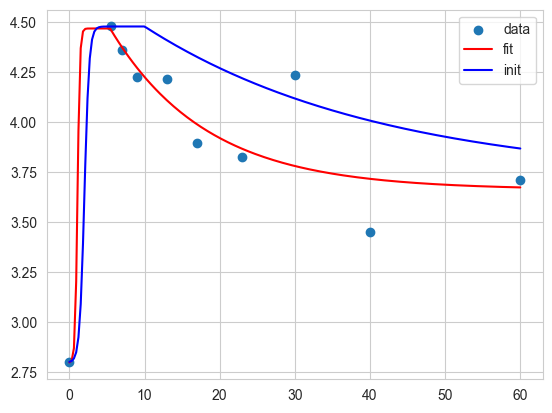

{'A': np.float64(2.7949522309849923), 'B': np.float64(1.6716154263340655), 'c1': np.float64(1.079573677424196), 'w1': np.float64(-0.8116679190108083), 'C': np.float64(-0.8654812702782212), 'c2': np.float64(5.412801163249135), 'w2': np.float64(-1.1078351142041996)}
Fitting row 29 (cJIMT1)


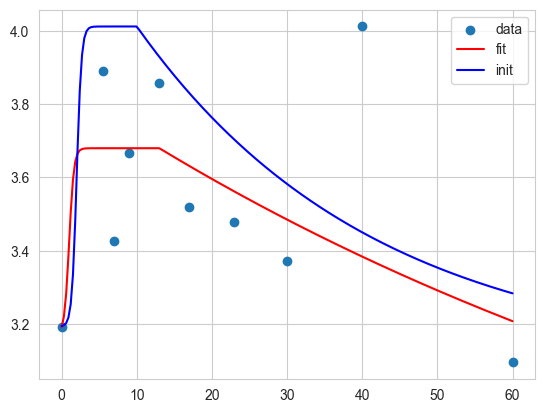

{'A': np.float64(3.1706190843166384), 'B': np.float64(0.5089832821679215), 'c1': np.float64(1.0020661516365232), 'w1': np.float64(-0.5000000000024161), 'C': np.float64(0.8293237452845882), 'c2': np.float64(12.999999761415546), 'w2': np.float64(-2.033834594548798)}
Fitting row 30 (cMCF10A)


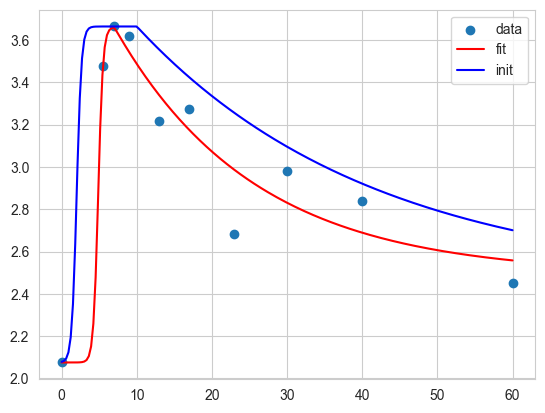

{'A': np.float64(2.0756004212685517), 'B': np.float64(1.5854507095013297), 'c1': np.float64(4.862151676580779), 'w1': np.float64(-0.5014095248530096), 'C': np.float64(-0.4145377800509116), 'c2': np.float64(6.999968439399417), 'w2': np.float64(-1.2699241618872696)}
Fitting row 31 (cMCF12A)


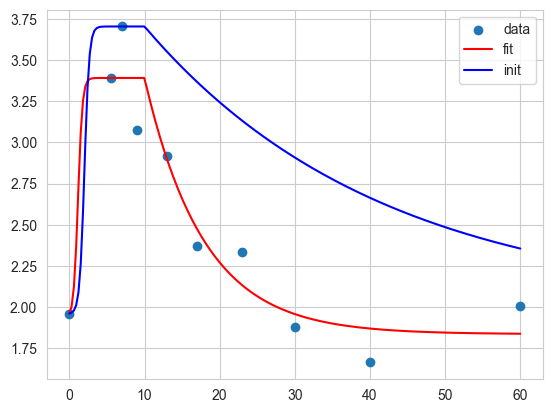

{'A': np.float64(1.9295604809175149), 'B': np.float64(1.4628963020043944), 'c1': np.float64(1.1508390629175773), 'w1': np.float64(-0.5345494812499572), 'C': np.float64(0.09519073135355671), 'c2': np.float64(9.991198605476027), 'w2': np.float64(-0.895234422700045)}
Fitting row 32 (cMCF7)


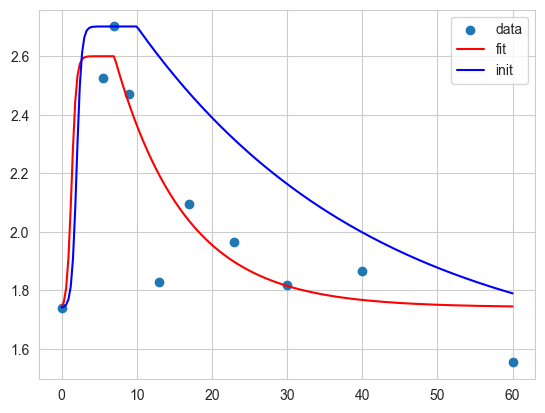

{'A': np.float64(1.728926764723285), 'B': np.float64(0.8718339979057587), 'c1': np.float64(1.3252804561739746), 'w1': np.float64(-0.5012186392868149), 'C': np.float64(-0.013534538806389832), 'c2': np.float64(7.000000038542441), 'w2': np.float64(-0.9702839162996096)}
Fitting row 33 (cMDAMB134VI)


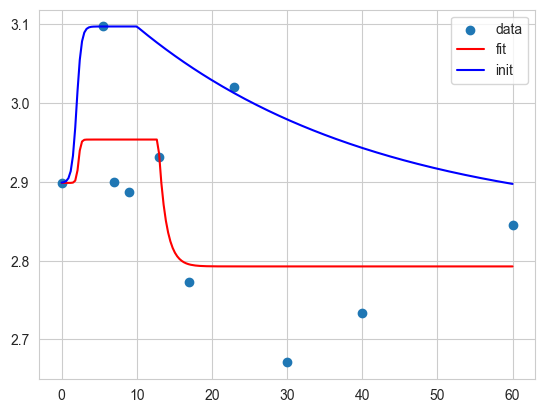

{'A': np.float64(2.898768433397391), 'B': np.float64(0.055096526253793604), 'c1': np.float64(2.2481508528410807), 'w1': np.float64(-0.8174051798508614), 'C': np.float64(0.10604036236774242), 'c2': np.float64(12.848349732981585), 'w2': np.float64(-7.093130031620021e-19)}
Fitting row 34 (cMDAMB157)


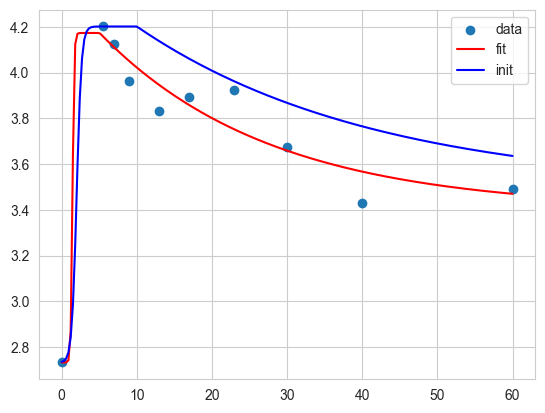

{'A': np.float64(2.7327416098706956), 'B': np.float64(1.4403835823799416), 'c1': np.float64(1.4467049816933613), 'w1': np.float64(-0.9658578891505825), 'C': np.float64(-0.668793785184876), 'c2': np.float64(5.056921173098166), 'w2': np.float64(-1.3560059567437277)}
Fitting row 35 (cMDAMB175VII)


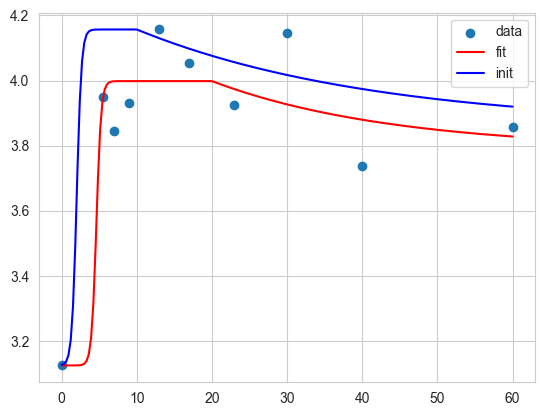

{'A': np.float64(3.125508234103411), 'B': np.float64(0.8729010839680144), 'c1': np.float64(4.624121980908767), 'w1': np.float64(-0.5000000000000001), 'C': np.float64(-0.6634336686051852), 'c2': np.float64(19.999999999999996), 'w2': np.float64(-1.379458965675817)}
Fitting row 36 (cMDAMB231)


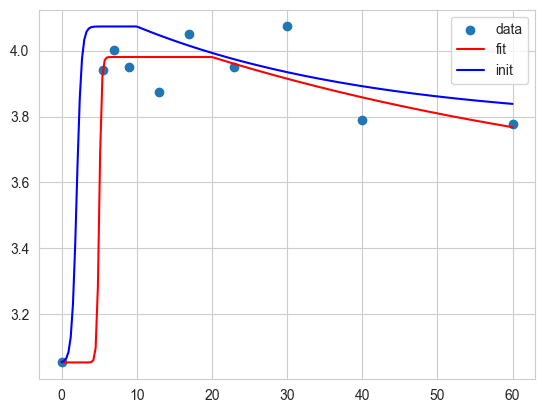

{'A': np.float64(3.054189329444889), 'B': np.float64(0.9263607370236079), 'c1': np.float64(4.999999999999896), 'w1': np.float64(-0.7982797563504093), 'C': np.float64(-0.4576481106362052), 'c2': np.float64(19.999999999999996), 'w2': np.float64(-1.820058612797166)}
Fitting row 37 (cMDAMB361)


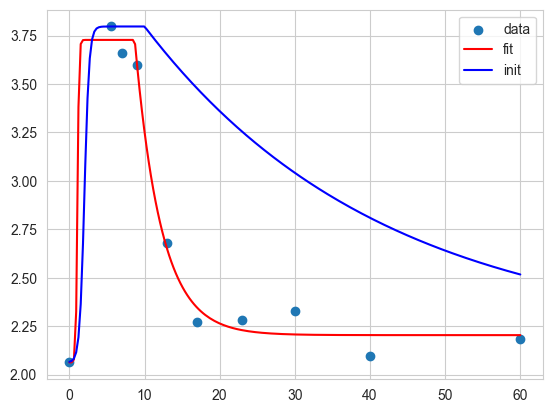

{'A': np.float64(2.0628107294001476), 'B': np.float64(1.6650669108495626), 'c1': np.float64(1.072300719401269), 'w1': np.float64(-0.9999977300390923), 'C': np.float64(-0.14117644922882075), 'c2': np.float64(8.69309988464321), 'w2': np.float64(-0.5438768865459106)}
Fitting row 38 (cMDAMB415)


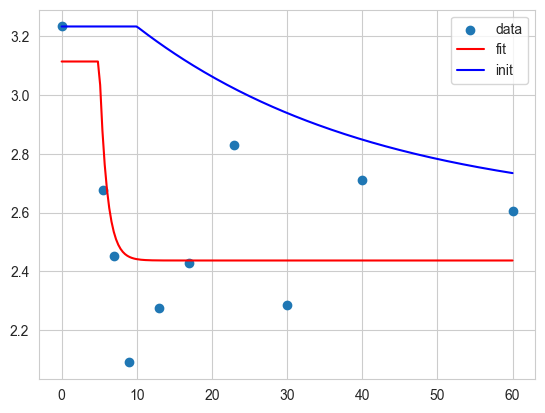

{'A': np.float64(3.1142579447233545), 'B': np.float64(1.1294026790900174e-23), 'c1': np.float64(1.0311290144358172), 'w1': np.float64(-0.9999924099120687), 'C': np.float64(0.6774397238838152), 'c2': np.float64(5.000000362668691), 'w2': np.float64(-4.670697973170061e-11)}
Fitting row 39 (cMDAMB453)


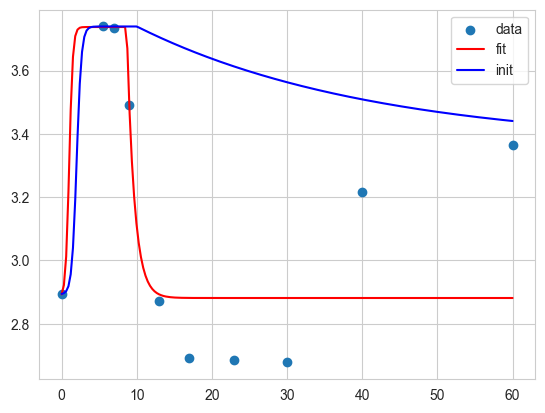

{'A': np.float64(2.880675347213442), 'B': np.float64(0.8569260507376277), 'c1': np.float64(1.0090162874895334), 'w1': np.float64(-0.6230708927295083), 'C': np.float64(-0.0007601293116510356), 'c2': np.float64(8.661703919168279), 'w2': np.float64(-8.462782668821077e-15)}
Fitting row 40 (cMDAMB468)


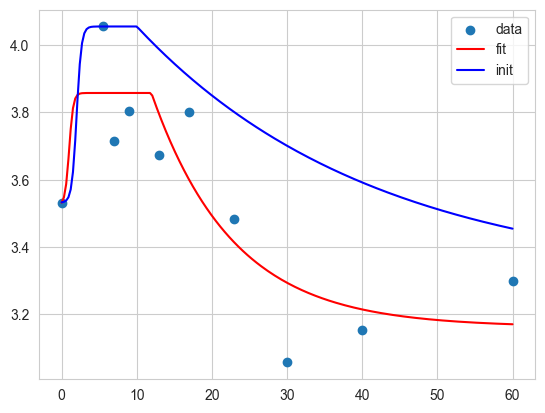

{'A': np.float64(3.5236406592042737), 'B': np.float64(0.3343629348793971), 'c1': np.float64(1.0002594053124665), 'w1': np.float64(-0.5628883663210993), 'C': np.float64(0.3613361451113082), 'c2': np.float64(11.941316432465227), 'w2': np.float64(-1.0350674329813172)}
Fitting row 41 (cMFM223)


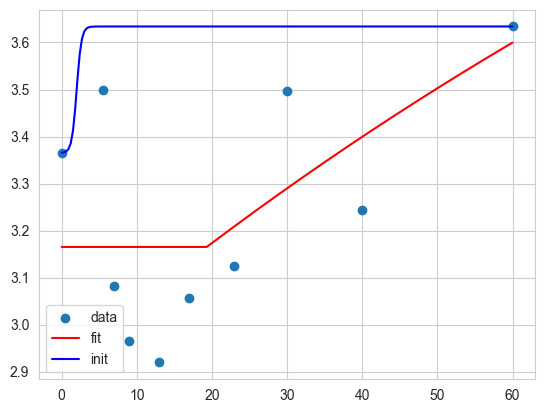

{'A': np.float64(3.1651151343700232), 'B': np.float64(3.2817262078077737e-23), 'c1': np.float64(1.1592243588306164), 'w1': np.float64(-0.5000000911006437), 'C': np.float64(-1.9999974299143852), 'c2': np.float64(19.31252298717577), 'w2': np.float64(-2.2201338916265745)}
Fitting row 42 (cMPE600)


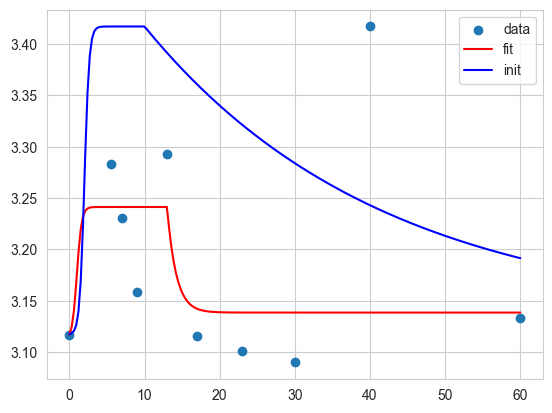

{'A': np.float64(3.1117832203641766), 'B': np.float64(0.1295465586532489), 'c1': np.float64(1.000287504553259), 'w1': np.float64(-0.5000500929902273), 'C': np.float64(-0.02677854056002606), 'c2': np.float64(13.000000059007668), 'w2': np.float64(-0.07989144164160548)}
Fitting row 43 (cMX1)


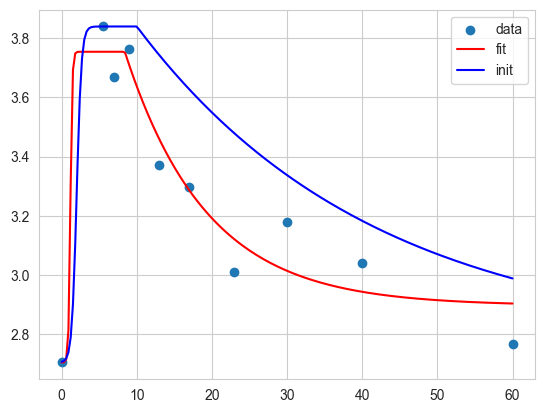

{'A': np.float64(2.7042256145791046), 'B': np.float64(1.0495696246513282), 'c1': np.float64(1.1672091856625317), 'w1': np.float64(-0.9122420936010326), 'C': np.float64(-0.1917649724690171), 'c2': np.float64(8.404928874844908), 'w2': np.float64(-1.0365604434491633)}
Fitting row 44 (cOCUBM)


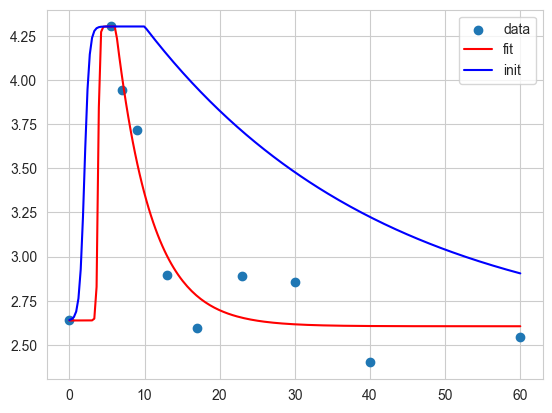

{'A': np.float64(2.6384746512941777), 'B': np.float64(1.6641864603639065), 'c1': np.float64(3.8228318675910242), 'w1': np.float64(-0.9997457554194311), 'C': np.float64(0.032608629920446025), 'c2': np.float64(6.1377531924356825), 'w2': np.float64(-0.6748865752001743)}
Fitting row 45 (cSKBR3)


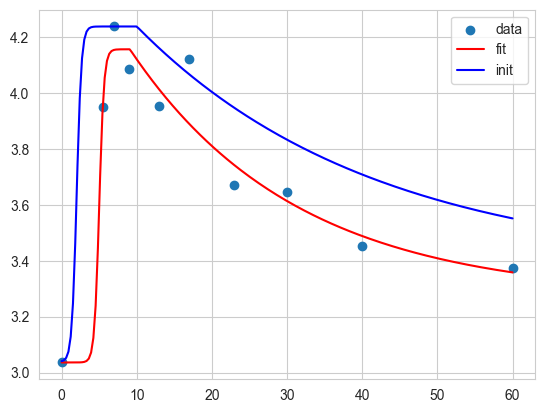

{'A': np.float64(3.0358982970154034), 'B': np.float64(1.120206262309137), 'c1': np.float64(4.999999999999999), 'w1': np.float64(-0.5000000000000001), 'C': np.float64(-0.23415922398595843), 'c2': np.float64(9.080318161405344), 'w2': np.float64(-1.3434034050891468)}
Fitting row 46 (cT47D)


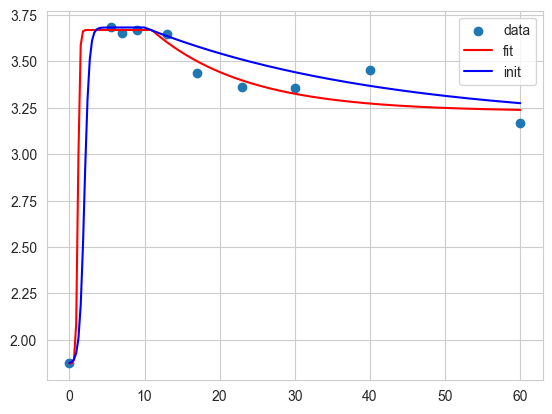

{'A': np.float64(1.8719946087977002), 'B': np.float64(1.7974746109737343), 'c1': np.float64(1.1434735551041828), 'w1': np.float64(-0.9240526539157394), 'C': np.float64(-1.358158568436985), 'c2': np.float64(10.959262530513238), 'w2': np.float64(-1.096284110657742)}
Fitting row 47 (cUACC3199)


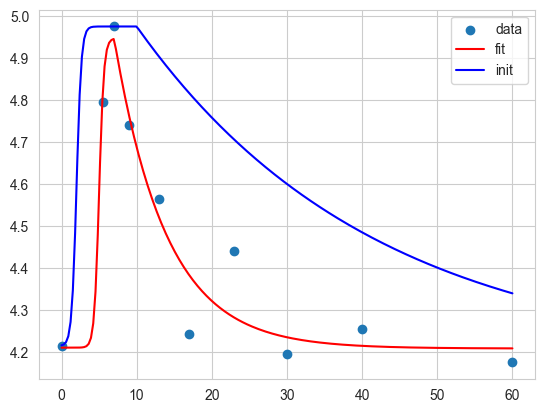

{'A': np.float64(4.209990930205056), 'B': np.float64(0.7368383914102113), 'c1': np.float64(4.9999795695853), 'w1': np.float64(-0.50000021037781), 'C': np.float64(0.002052357649363676), 'c2': np.float64(7.000000012841905), 'w2': np.float64(-0.8409949723832423)}
Fitting row 48 (cUACC812)


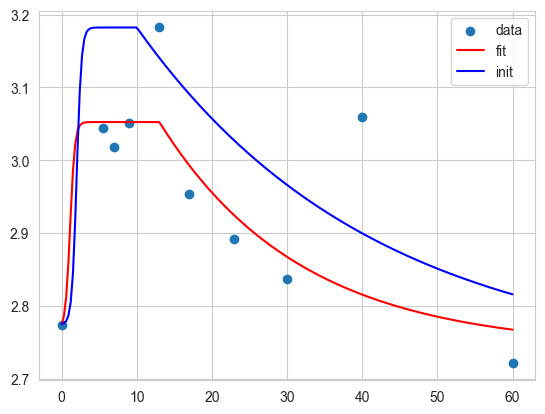

{'A': np.float64(2.7667971697917464), 'B': np.float64(0.2857738265789398), 'c1': np.float64(1.1321544079870804), 'w1': np.float64(-0.5000605423725132), 'C': np.float64(0.024518182423028754), 'c2': np.float64(13.000000005675997), 'w2': np.float64(-1.2720200574542966)}
Fitting row 49 (cUACC893)


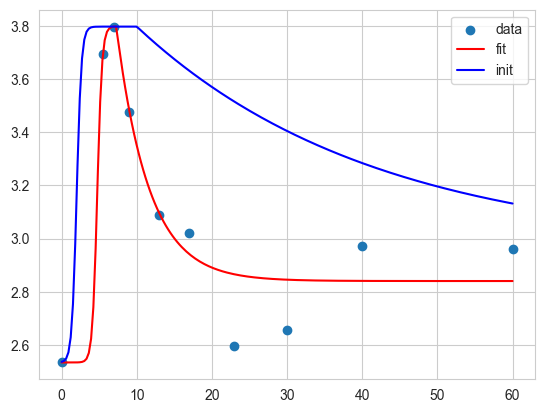

{'A': np.float64(2.533518820418805), 'B': np.float64(1.265248301620763), 'c1': np.float64(4.734370381310192), 'w1': np.float64(-0.5000260790923442), 'C': np.float64(-0.30655793371154866), 'c2': np.float64(7.264323652333784), 'w2': np.float64(-0.6364089212057827)}
Fitting row 50 (cZR751)


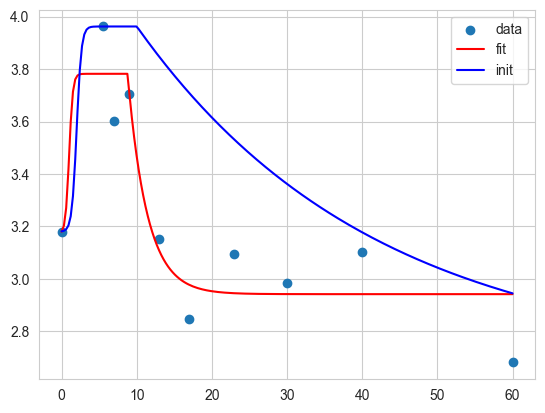

{'A': np.float64(3.169999900112248), 'B': np.float64(0.6120869725024594), 'c1': np.float64(1.0000475827343047), 'w1': np.float64(-0.6129520149549248), 'C': np.float64(0.22828992438296566), 'c2': np.float64(8.764925462836656), 'w2': np.float64(-0.4150269367513263)}
Fitting row 51 (cZR7530)


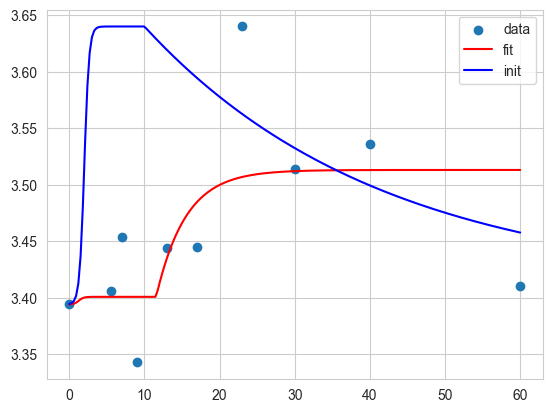

{'A': np.float64(3.393970594032192), 'B': np.float64(0.00683861079322482), 'c1': np.float64(1.266783789087458), 'w1': np.float64(-0.5000040464083829), 'C': np.float64(-0.11902918477925796), 'c2': np.float64(11.559460078508486), 'w2': np.float64(-0.5967879809332618)}


In [245]:
params_all = []
for iloc in range(len(df_ts)):
    print(f"Fitting row {iloc} ({df_ts.index[iloc]})")
    df_ts.iloc[iloc,:].values

    y = df_ts.iloc[iloc,:].values
    x = df_ts.columns.values.astype(float)
    x = x[~np.isnan(y)]
    y = y[~np.isnan(y)]
    res = fit_double_sigmoid(x, y, plot=True)
    params_all.append({'cell_line': df_ts.index[iloc], **res.params})
    print(res.params)

In [200]:
df_param = pd.DataFrame(params_all).set_index('cell_line')

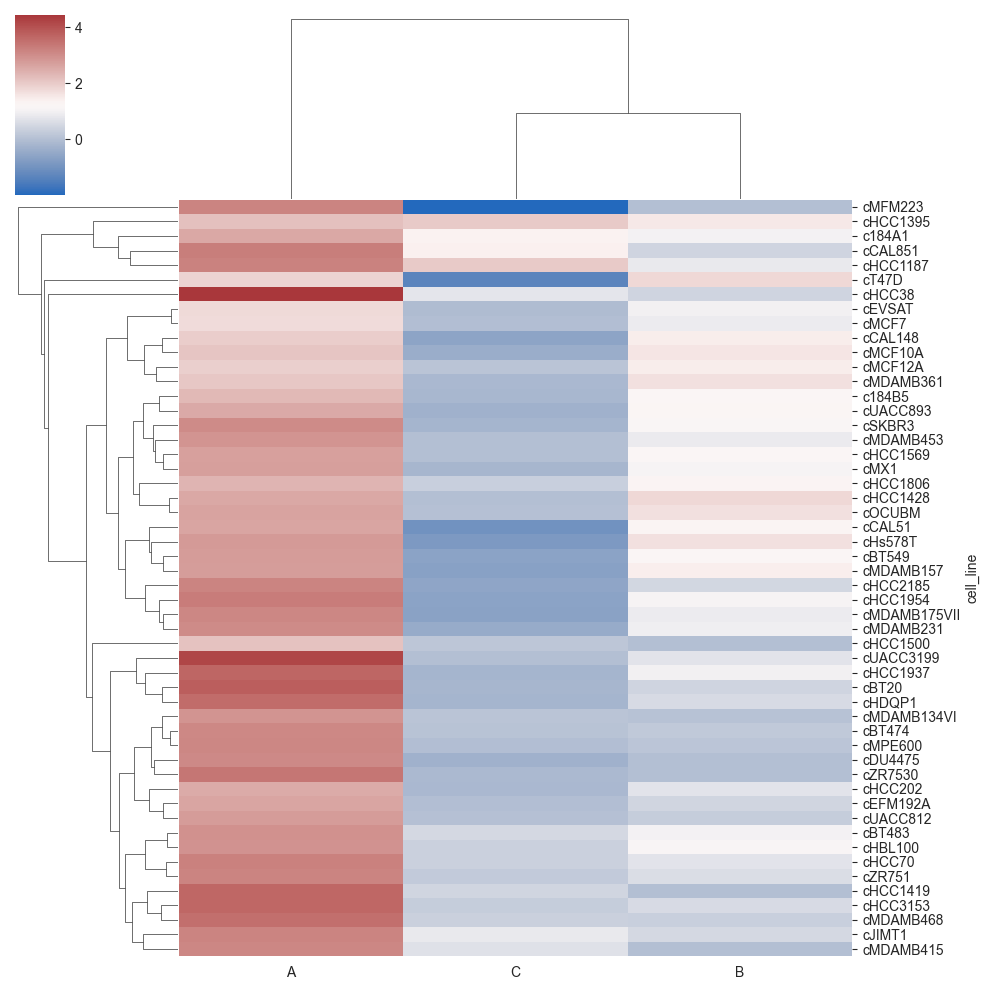

In [201]:
sns.clustermap(df_param[['A','C','B']], yticklabels=True, cmap='vlag')

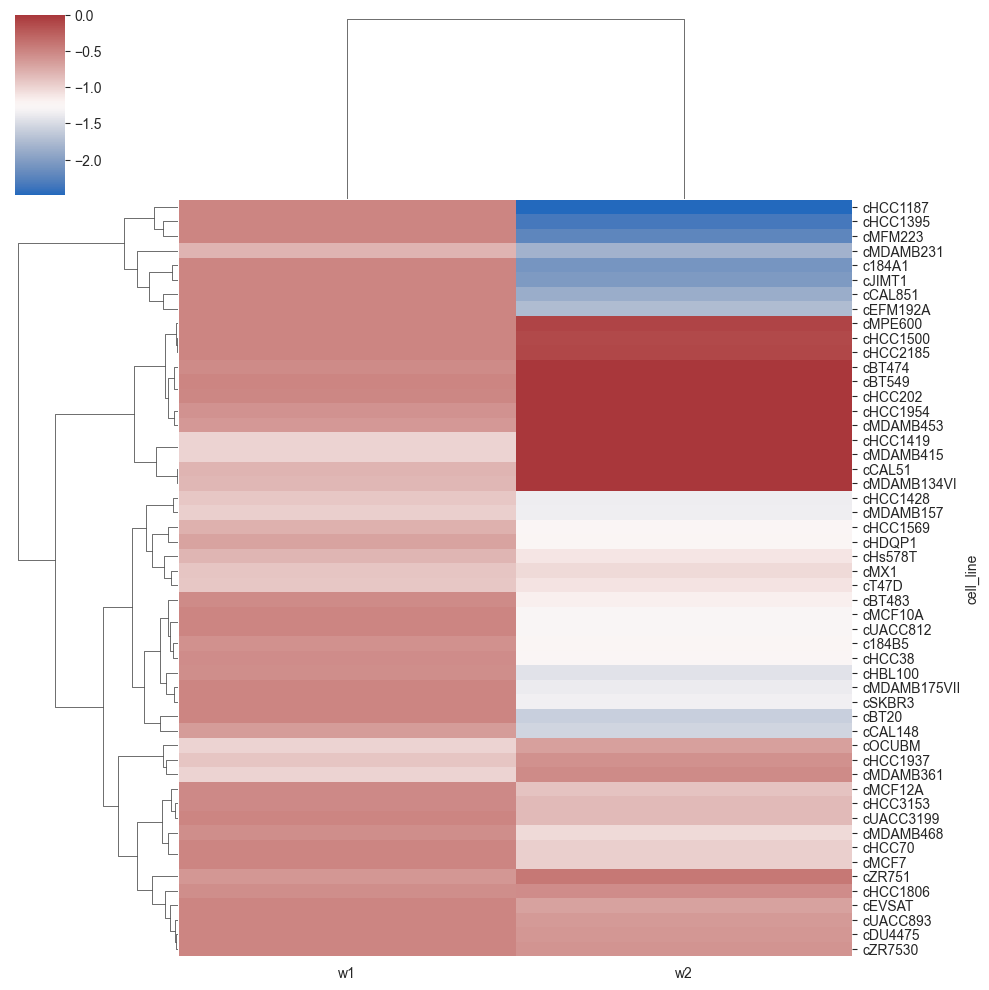

In [202]:
sns.clustermap(df_param[['w1', 'w2']], yticklabels=True, cmap='vlag')

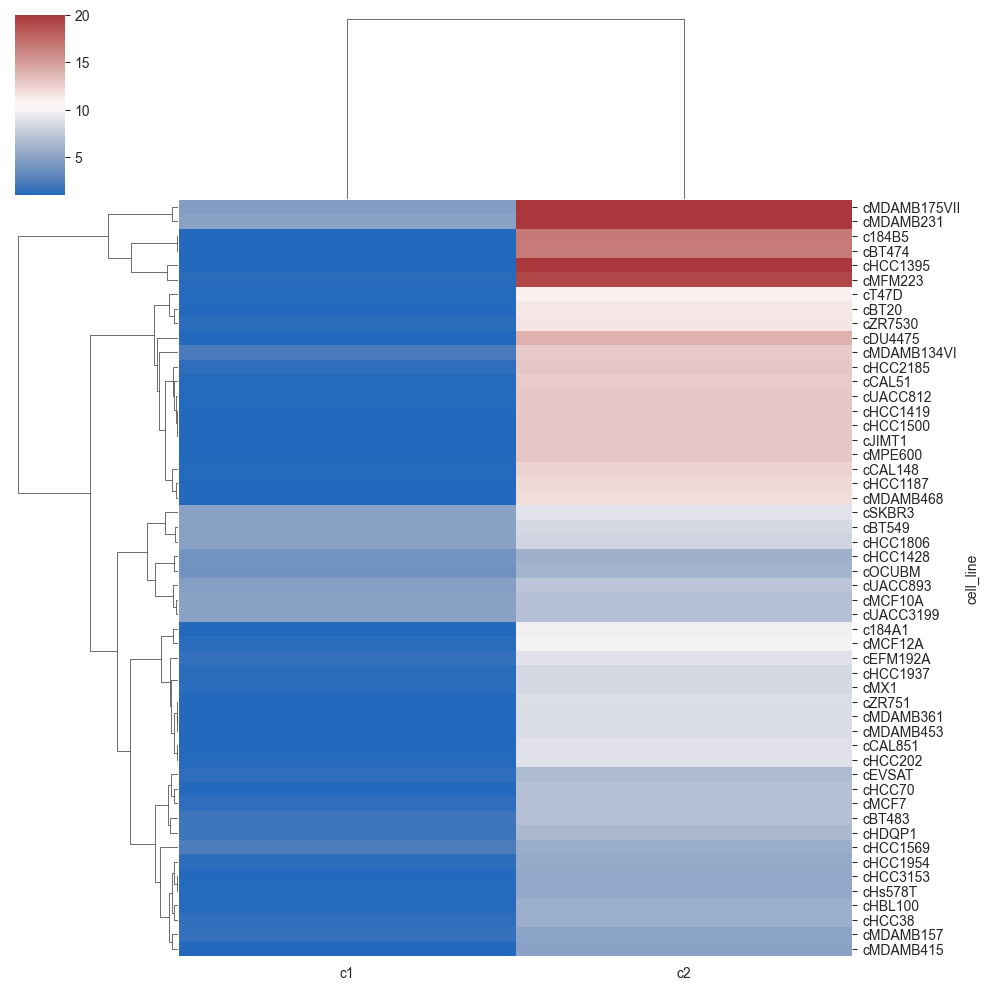

In [203]:
sns.clustermap(df_param[['c1', 'c2']], yticklabels=True, cmap='vlag')

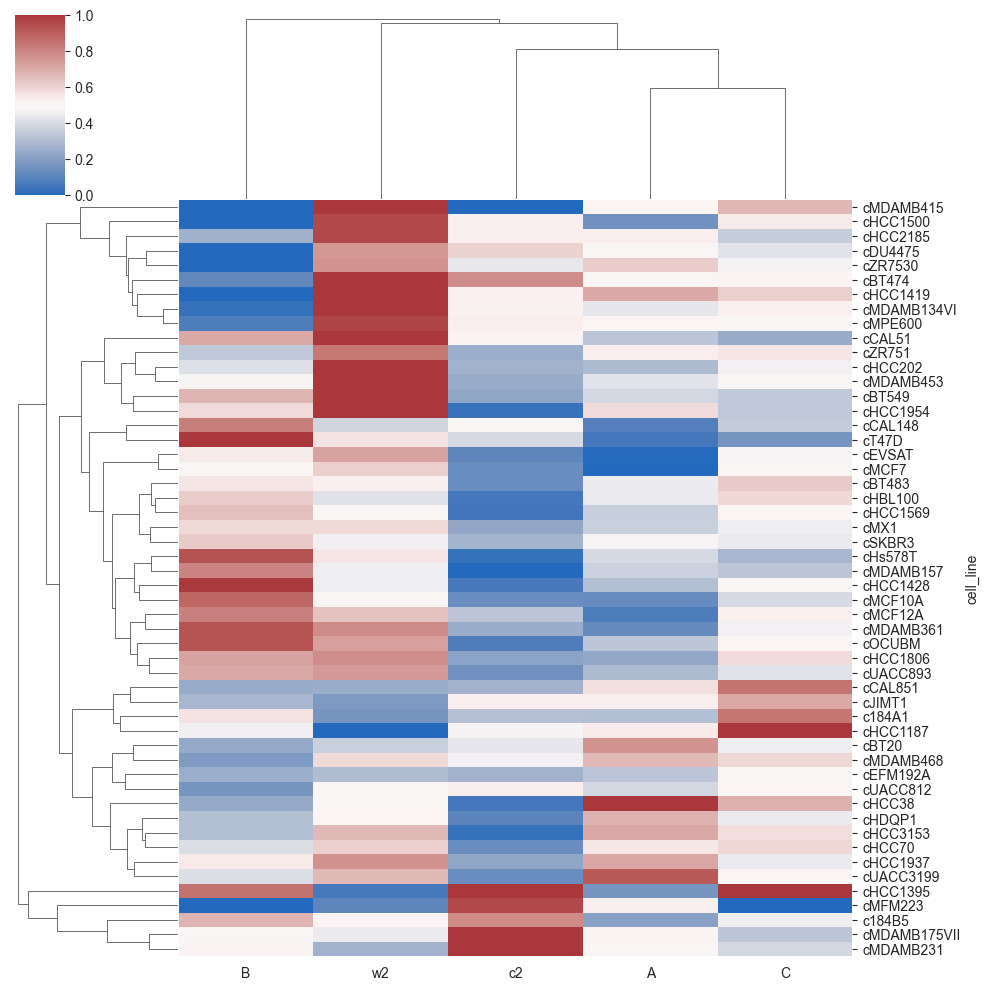

In [204]:
sns.clustermap(df_param[['A','B','C','w2', 'c2']], yticklabels=True, cmap='vlag', standard_scale=1)

In [205]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
embed = pca.fit_transform(df_param)

In [216]:
embed

array([[-0.39968946, -0.94574542,  1.68311528],
       [ 6.61815511, -0.60147899, -0.11591574],
       [ 1.40156804, -0.86980256,  0.27726619],
       [ 6.54502536, -0.81525596, -0.79229751],
       [-3.12960516, -0.21339692,  0.55746929],
       [-1.85469368,  3.10560889, -0.82624167],
       [ 2.29556466, -0.49001   , -0.14688763],
       [ 2.58238524, -0.49511047, -1.48504488],
       [-1.08043663, -1.12026379,  1.57781561],
       [ 3.89989304, -0.85465279, -0.60167312],
       [-1.07754373, -0.46769901,  0.46133134],
       [-3.52997357, -0.55555213, -0.31732762],
       [-4.32464266, -0.84859182,  0.6188102 ],
       [ 2.02625047, -1.05846028,  2.41704411],
       [ 9.8767578 , -0.73971291,  2.16663704],
       [ 2.76933174, -0.95838179, -0.45328277],
       [-4.28930489,  2.08737215,  0.51554179],
       [ 2.88356913, -0.91407843, -0.70152065],
       [-4.42091731,  0.32890319,  0.29434584],
       [-2.05819694,  2.92211157,  0.18896621],
       [-1.76976734, -0.68597785, -0.376

In [263]:
rtks = ['EGFR', 'ERBB2', 'ERBB3', 'ERBB4', 'PGR', 'ESR1']
ligands = ['AREG', 'EREG', 'BTC', 'HBEGF', 'EPGN', 'NRG1', 'NRG2' ,'NRG3', 'NRG4']
emt = ['VIM', 'CDH1', 'CDH2', 'ACTA2', 'CTNNB1', 'DDR2']
rabs = [
    # https://doi.org/10.1111/febs.15453
    # E, endosome;
    # EE, early endosome;
    # ERC, endocytic recycling compartment
    # LE, late endosome
    # RE, recycling endosome
    # PM, plasma membrane
    'RAB1A', # EE/ER
    'RAB1B', # ER
    'RAB3B', # RE
    'RAB3C', # RE
    'RAB4A', # EE/RE
    'RAB4B', # EE/RE
    'RAB5A', # EE
    'RAB5B', # EE/PM
    'RAB5C', # EE
    'RAB7A', # LE
    # 'RAB7B', # LE, missing
    'RAB8A', # RE
    'RAB9A', # LE
    'RAB9B', # LE
    'RAB11A', # RE
    'RAB11B', # RE
    'RAB13', # RE
    'RAB14', # EE
    'RAB15', # EE/RE
    'RAB17', # RE
    'RAB21', # EE
    'RAB22A', # EE/RE
    'RAB25', # RE
    # 'RAB29', # RE, missing
    'RAB35', # EE
    'RAB36', # RE
]
cavs = ['CAV1', 'CAV2', 'CAV3']
markers = rtks + ligands + rabs + cavs + emt

df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx[df_tx['observableId'].isin(markers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px[df_px['observableId'].isin(markers)].pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_p = df[df['simulationConditionId'].str.split('__').str[1]=='full'].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)

for marker in markers:
    df_p[f't{marker}'] = df_tx.T[marker]
    if marker in df_px.index:
        df_p[f'p{marker}'] = df_px.T[marker]

In [264]:
import synapseclient
syn = synapseclient.Synapse()
syn.login()
file_id_table = pd.read_csv(
    syn.get("syn20631269").path, index_col=0
).set_index("fileID")
annotations = ['PAM50', 'Neve', 'Marcotte', 'Gene.cluster', 'Classification', 'primary.tumor', 'formed.mets', 'Growth.medium', 'Origin', 'AR', 'PGR', 'HER2', 'ERa', 'Lehmann', 'Ethnicity', 'cell_line']
df_annotation = file_id_table[annotations].groupby('cell_line').agg(
    lambda x: ' '.join(np.unique([str(x) for x in x]))
).reset_index()
df_annotation['cell_line'] = df_annotation['cell_line'].apply(lambda x: f'c{x}')
df_annotation = df_annotation.rename(columns={'cell_line': 'preequilibrationConditionId'}).set_index('preequilibrationConditionId')

for annotation in annotations:
    if annotation == 'cell_line':
        continue
    df_p[annotation] = df_annotation[annotation]

Welcome, Fabian Froehlich!

[syn20631269:FileID_table.csv]: Found existing file at /Users/frohlif/.synapseCache/298/42318298/FileID_table.csv, skipping download.


In [265]:
df_param

,A,B,c1,w1,C,c2,w2
cell_line,,,,,,,
c184A1,2.575852,1.005461e+00,1.054412,-0.500010,1.370116,9.692704,-2.086062e+00
c184B5,2.276765,1.216916e+00,1.000132,-0.577344,-0.172958,16.743852,-1.229824e+00
cBT20,3.788503,4.256137e-01,1.006647,-0.500000,-0.196070,11.482726,-1.594096e+00
cBT474,3.083759,2.044397e-01,1.000153,-0.540213,0.064362,16.683925,-1.845009e-13
cBT483,2.939478,9.996318e-01,1.777006,-0.540936,0.493085,7.000000,-1.176883e+00
cBT549,2.774729,1.213888e+00,4.959265,-0.503739,-0.632925,8.383853,-6.907748e-35
cCAL148,1.959434,1.469392e+00,1.116580,-0.646842,-0.596689,12.408957,-1.543892e+00
cCAL51,2.624462,1.273045e+00,1.114804,-0.806691,-1.031006,12.745897,-9.293813e-16
cCAL851,3.271743,4.389736e-01,1.000094,-0.500000,1.386510,9.000000,-1.875365e+00


In [266]:
df_p['PC1'] = embed[:,0]
df_p['PC2'] = embed[:,1]
df_p['PC3'] = embed[:,2]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_17565/1145861899.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p['PC2'] = embed[:,1]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_17565/1145861899.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p['PC3'] = embed[:,2]



<Axes: >

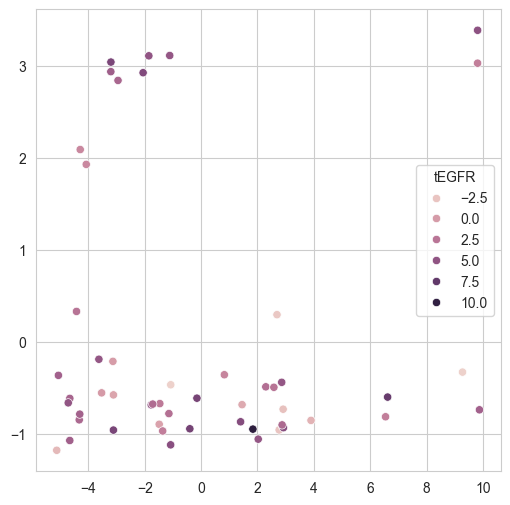

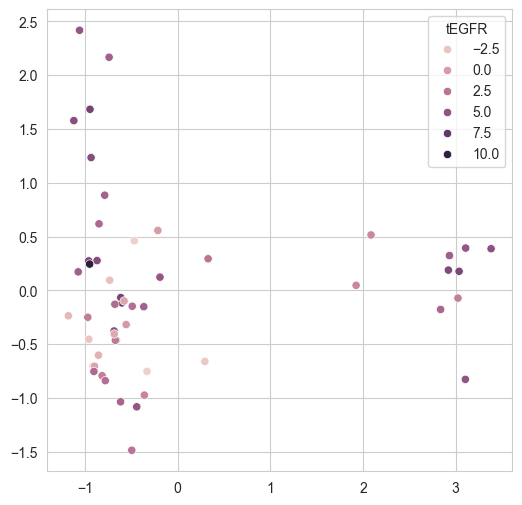

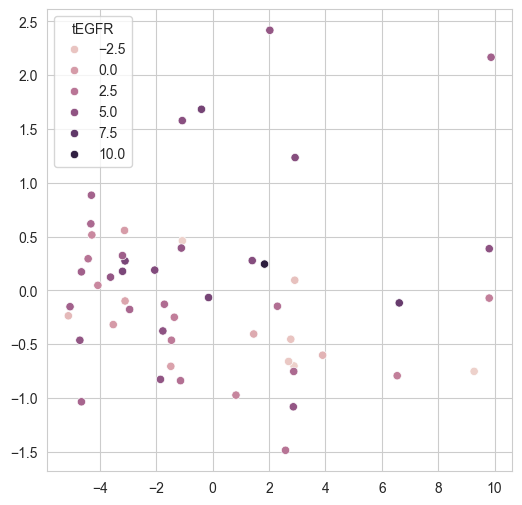

In [267]:
import seaborn as sns
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df_p['tEGFR'])
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,1], y=embed[:,2], hue=df_p['tEGFR'])
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,0], y=embed[:,2], hue=df_p['tEGFR'])

<Axes: >

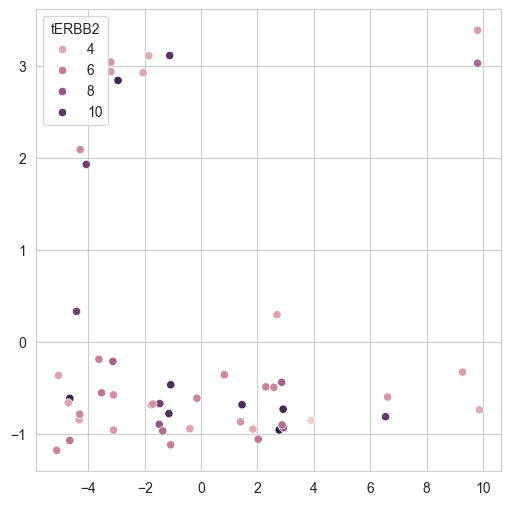

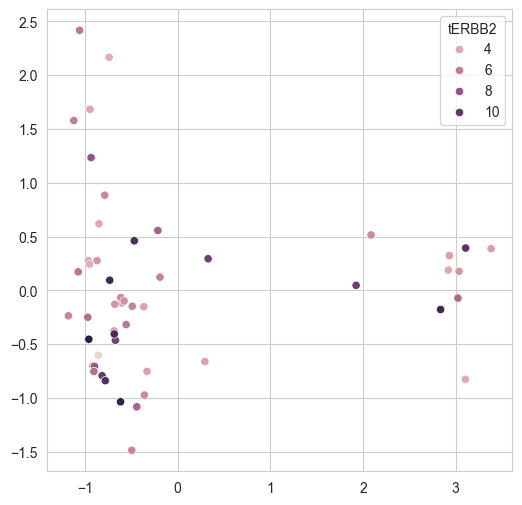

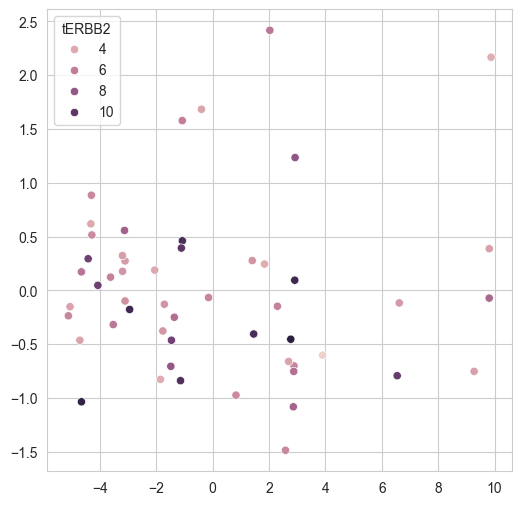

In [268]:
import seaborn as sns
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=df_p['tERBB2'])
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,1], y=embed[:,2], hue=df_p['tERBB2'])
plt.figure(figsize=(6,6))
sns.scatterplot(x=embed[:,0], y=embed[:,2], hue=df_p['tERBB2'])

In [269]:
for par in ['A','B','C','c1','c2','w1','w2']:
    df_p[par] = df_param[par]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_17565/1085320566.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p[par] = df_param[par]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_17565/1085320566.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_p[par] = df_param[par]

[WARNING] /var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_17565/1085320566.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

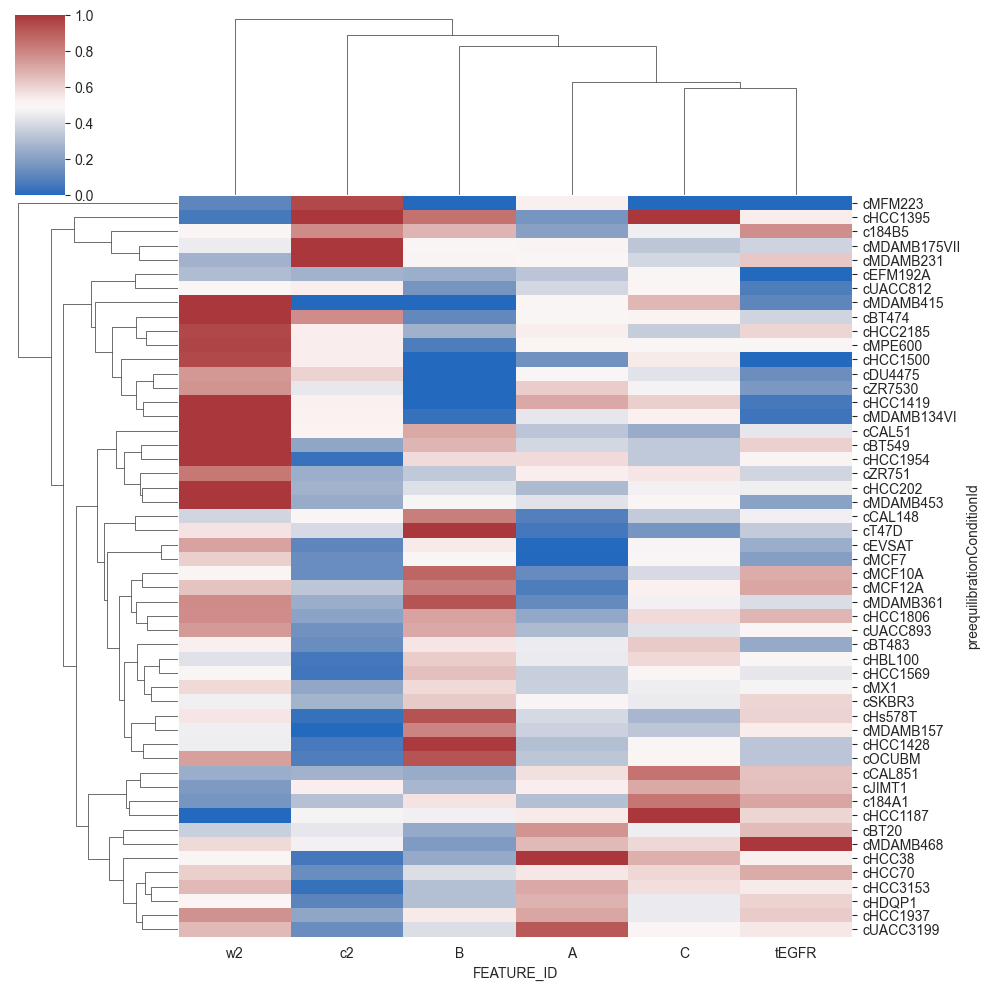

In [270]:
sns.clustermap(df_p[['A','B','C','w2', 'c2', 'tEGFR']], yticklabels=True, cmap='vlag', standard_scale=1)

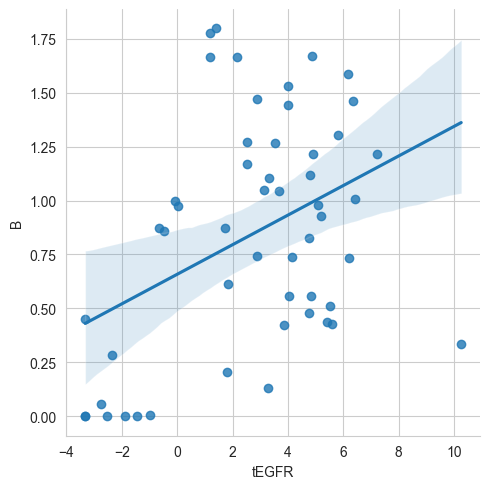

In [271]:
sns.lmplot(df_p, y='B', x='tEGFR')

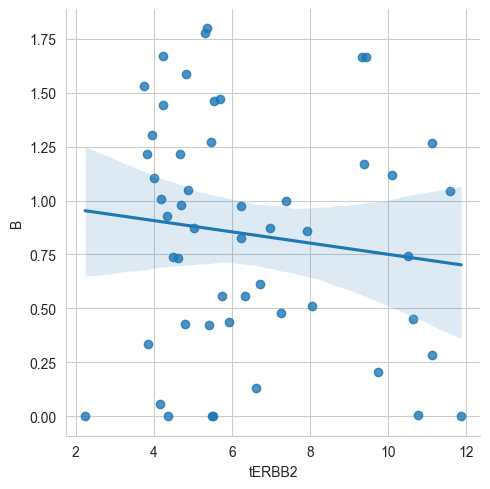

In [272]:
sns.lmplot(df_p, y='B', x='tERBB2')

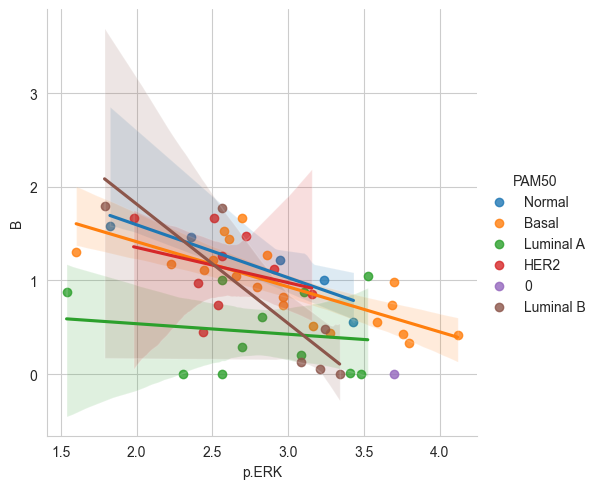

In [273]:
sns.lmplot(df_p, y='B', x='p.ERK', hue='PAM50')

<Axes: xlabel='PAM50', ylabel='B'>

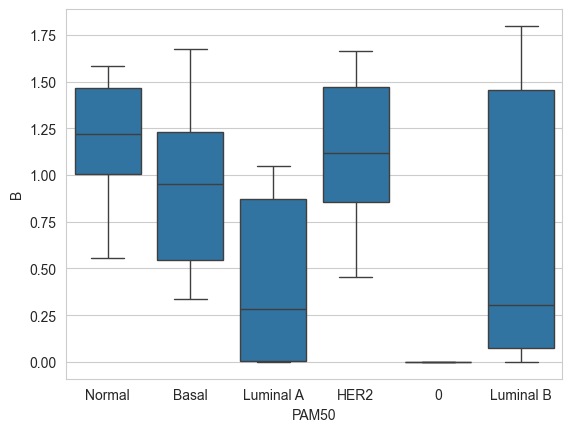

In [251]:
sns.boxplot(df_p, y='B', x='PAM50')

<Axes: xlabel='Neve', ylabel='B'>

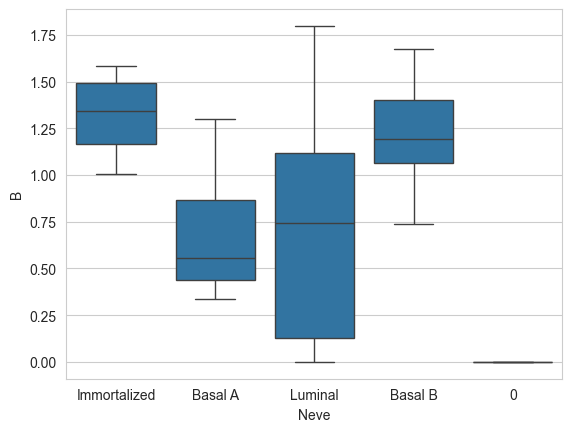

In [252]:
sns.boxplot(df_p, y='B', x='Neve')

<Axes: xlabel='Neve', ylabel='A'>

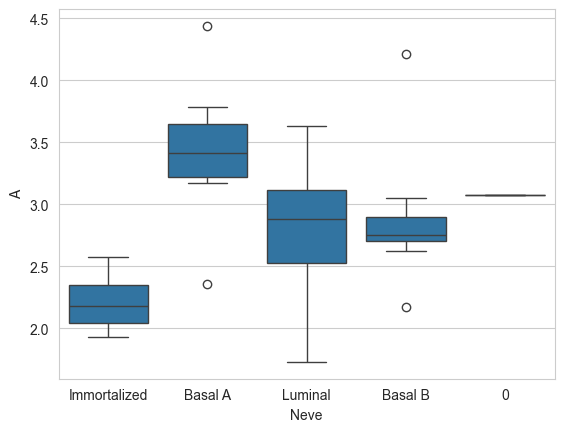

In [256]:
sns.boxplot(df_p, y='A', x='Neve')

<Axes: xlabel='PAM50', ylabel='A'>

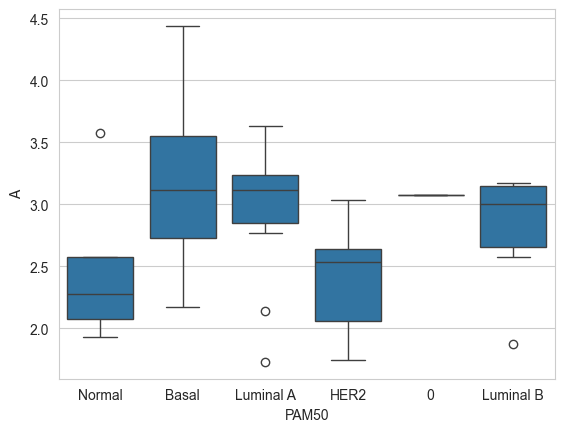

In [257]:
sns.boxplot(df_p, y='A', x='PAM50')

<Axes: xlabel='PAM50', ylabel='C'>

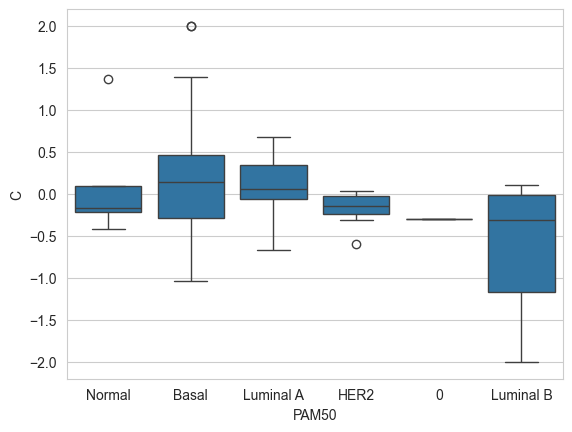

In [258]:
sns.boxplot(df_p, y='C', x='PAM50')

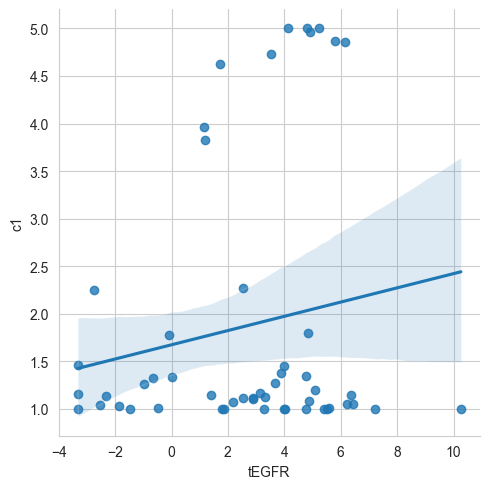

In [244]:
sns.lmplot(df_p, y='c1', x='tEGFR')

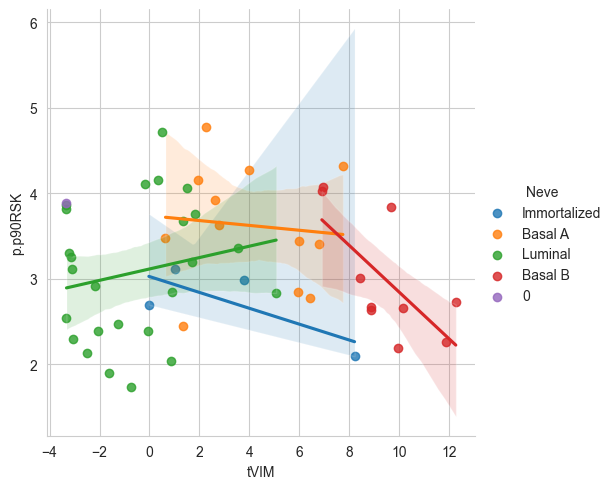

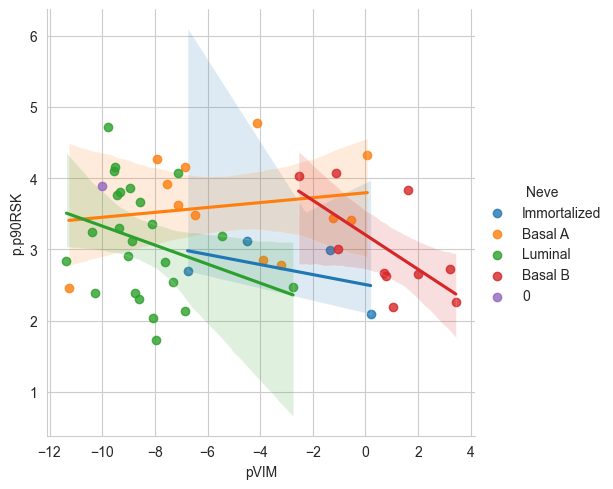

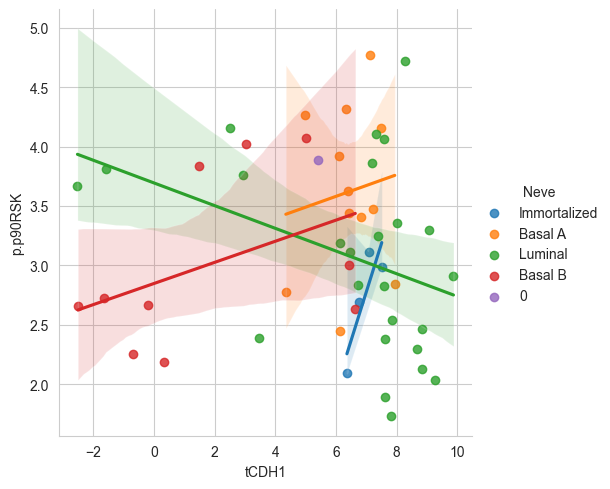

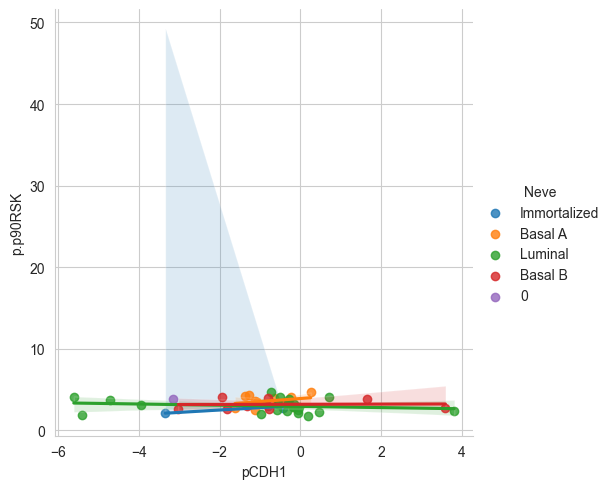

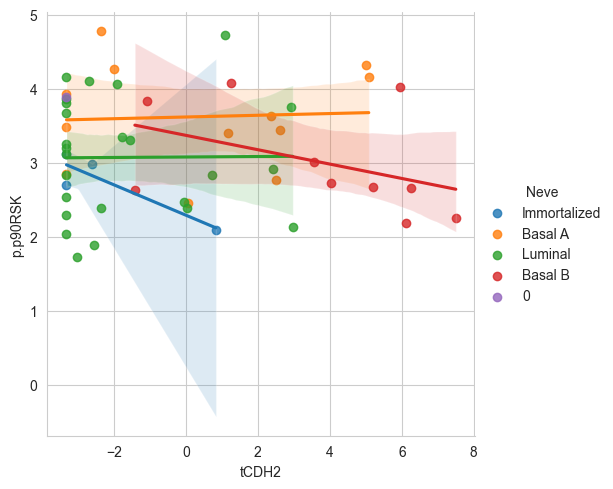

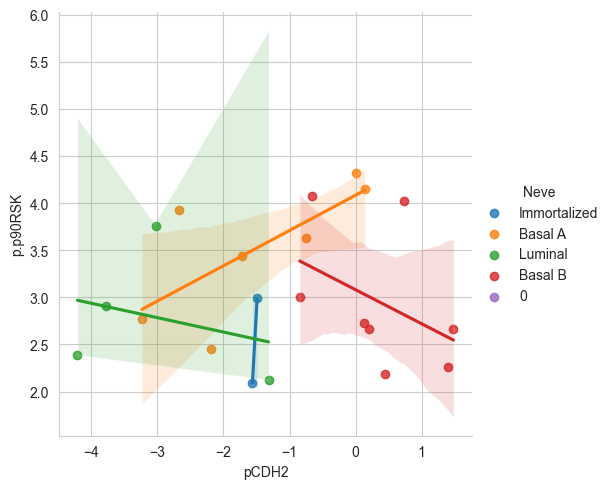

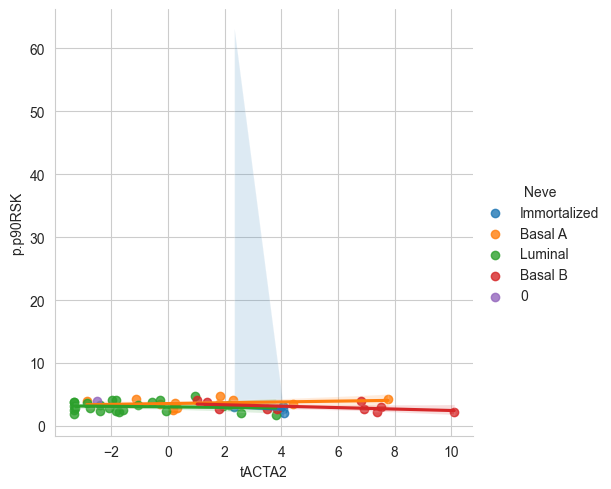

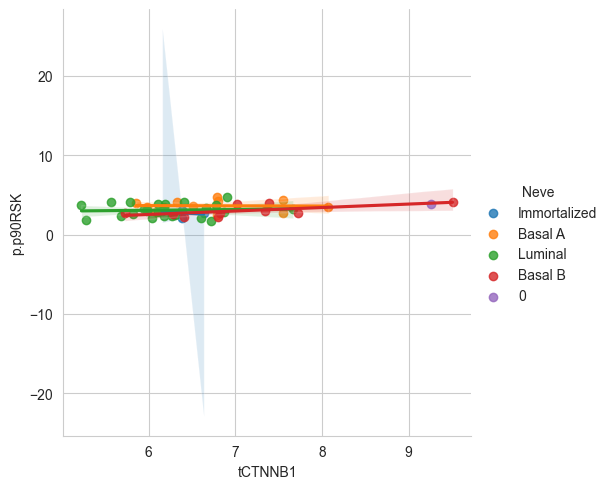

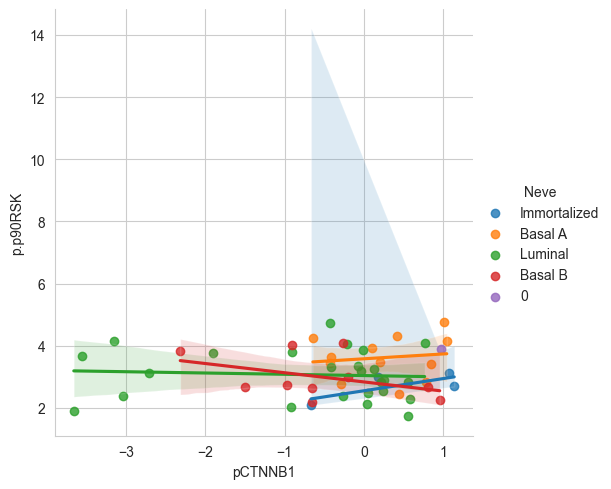

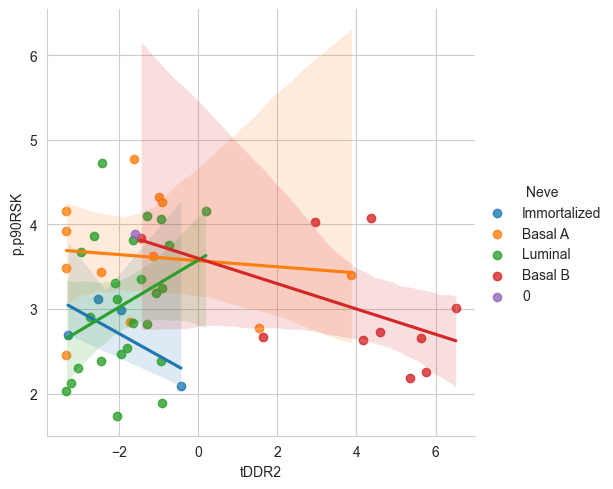

In [282]:
for m in emt:
    sns.lmplot(df_p, y='p.p90RSK', x=f't{m}', hue='Neve')
    if f'p{m}' in df_p.columns:
        sns.lmplot(df_p, y='p.p90RSK', x=f'p{m}', hue='Neve')